# Surface Defect Detection on KolektorSDD2
## A Comparative Study: PCA vs. Convolutional Autoencoder vs. Supervised CNNs

**Group Members:** Anton Gasenzer (185924), Martin Dieselhorst (185897), Max Knopp (185893)


**Research Question:** How does label scarcity influence the choice between supervised and unsupervised learning for surface defect detection?

**Dataset Source:** https://go.vicos.si/kolektorsdd2

**Methods:**
1. PCA reconstruction error (unsupervised baseline)
2. Convolutional Autoencoder with hyperparameter sweep (unsupervised)
3. Supervised CNN iterations (v1, v2, v2_tuned) + ResNet50 transfer learning
4. Crossover experiment varying labeled defect count

**Note:** PCA and the CAE are fully unsupervised, so both representation learning and threshold calibration use only normal validation images. The supervised CNNs use labeled validation data for threshold selection (F1-max).

## Import Required Packages

In [ ]:
# pip installs
#!pip install keras-tuner
#!pip install tabulate
#!pip install tensorboard
#!pip install kneed

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc
import shutil
import os
from pathlib import Path
from PIL import Image
from tabulate import tabulate

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # turning off error messages

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers, losses
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    f1_score, precision_score, recall_score, classification_report,
    ConfusionMatrixDisplay
)
from scipy.ndimage import gaussian_filter
from kneed import KneeLocator

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1778877109.235186    1874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778877110.642770    1874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Data Organization

Raw images come mixed into a single folder with defect masks alongside. Here we sort them into damaged/ and non_damaged/ subfolders for train and test, which all downstream loading assumes.

In [ ]:
# Organize raw dataset into damaged / non_damaged folders by mask content

RAW_DATA_DIR = Path('KolektorSDDv2')               # adjust to point to the raw dataset
ORGANIZED_DATA_DIR = Path('KolektorSDD2_organized') # adjust to point where the cleaned strucutre should be stored

def organize_split(raw_split_dir, organized_split_dir):
    (organized_split_dir / 'non_damaged').mkdir(parents=True, exist_ok=True)
    (organized_split_dir / 'damaged').mkdir(parents=True, exist_ok=True)

    image_paths = sorted(p for p in raw_split_dir.glob('*.png') if not p.stem.endswith('_GT'))

    n_normal, n_damaged, n_skipped = 0, 0, 0

    for img_path in image_paths:
        mask_path = img_path.parent / (img_path.stem + '_GT.png')

        if not mask_path.exists():
            print(f"Warning: no mask for {img_path.name}, skipping")
            n_skipped += 1
            continue

        mask = np.array(Image.open(mask_path))
        is_damaged = bool((mask > 0).any())

        target_class = 'damaged' if is_damaged else 'non_damaged'
        target_dir = organized_split_dir / target_class

        shutil.copy2(img_path, target_dir / img_path.name)
        shutil.copy2(mask_path, target_dir / mask_path.name)

        if is_damaged:
            n_damaged += 1
        else:
            n_normal += 1

    print(f"  {raw_split_dir.name}: {n_normal} normal, {n_damaged} damaged, {n_skipped} skipped")

# Only organize if it hasn't been done yet — re-running the notebook stays fast
if not ORGANIZED_DATA_DIR.exists():
    print(f"Organizing raw dataset from {RAW_DATA_DIR} → {ORGANIZED_DATA_DIR}")
    t0 = time.time()
    organize_split(RAW_DATA_DIR / 'train', ORGANIZED_DATA_DIR / 'train')
    organize_split(RAW_DATA_DIR / 'test',  ORGANIZED_DATA_DIR / 'test')
    print(f"Organization complete in {time.time() - t0:.1f}s")
else:
    print(f"Organized dataset already exists at {ORGANIZED_DATA_DIR}, skipping.")

Organized dataset already exists at KolektorSDD2_organized, skipping.


In [ ]:
# Set Train/Test Directories
DATA_DIR  = ORGANIZED_DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

print(f"Train dir exists: {TRAIN_DIR.exists()}")
print(f"Test dir exists:  {TEST_DIR.exists()}")

Train dir exists: True
Test dir exists:  True


## Pre-Resize EDA

Before resizing to 288x96 we check native dimensions, defect size loss, and how the smallest defects look post-resize. The goal is to confirm the resize does not destroy detectability.

In [ ]:
IMG_H, IMG_W = 288, 96   # target size for resizing in load_images

In [ ]:
# Collect native (width, height) for all non-mask PNGs and summarize size distribution
from collections import Counter

def collect_native_sizes(folder):
    sizes = []
    for p in folder.glob('*.png'):
        if p.stem.endswith('_GT'):
            continue
        with Image.open(p) as img:
            sizes.append(img.size)  # (width, height)
    return sizes

native_sizes = []
for split in ['train', 'test']:
    for cls in ['non_damaged', 'damaged']:
        native_sizes.extend(collect_native_sizes(ORGANIZED_DATA_DIR / split / cls))

size_counts = Counter(native_sizes)

print(f"Total images inspected: {len(native_sizes)}")
print(f"Number of unique (width, height) pairs: {len(size_counts)}\n")
print("Most common native sizes:")
for (w, h), count in size_counts.most_common(10):
    print(f"  {w} × {h}: {count} images")

# Compare to the target resize
print(f"\nTarget resize: {IMG_W} × {IMG_H}")
print(f"Aspect ratio of target: {IMG_W / IMG_H:.3f}")

# If sizes vary, check the range of scaling factors
if len(size_counts) > 1:
    widths = [w for w, h in native_sizes]
    heights = [h for w, h in native_sizes]
    print(f"\nNative widths:  min={min(widths)}, max={max(widths)}")
    print(f"Native heights: min={min(heights)}, max={max(heights)}")
    print(f"Width scaling factors range: {IMG_W/max(widths):.3f} to {IMG_W/min(widths):.3f}")
    print(f"Height scaling factors range: {IMG_H/max(heights):.3f} to {IMG_H/min(heights):.3f}")

Total images inspected: 3335
Number of unique (width, height) pairs: 601

Most common native sizes:
  229 × 638: 45 images
  229 × 639: 43 images
  230 × 638: 43 images
  230 × 636: 41 images
  229 × 636: 41 images
  231 × 637: 38 images
  229 × 634: 37 images
  230 × 640: 36 images
  230 × 637: 36 images
  229 × 637: 36 images

Target resize: 96 × 288
Aspect ratio of target: 0.333

Native widths:  min=184, max=241
Native heights: min=597, max=665
Width scaling factors range: 0.398 to 0.522
Height scaling factors range: 0.433 to 0.482


Native defect sizes  — min=23, median=2273, max=43869
Resized defect sizes — min=4, median=431, max=8330

Defects with 0 pixels after resize (lost entirely): 0 / 356
Defects below 10 pixels after resize: 1 / 356


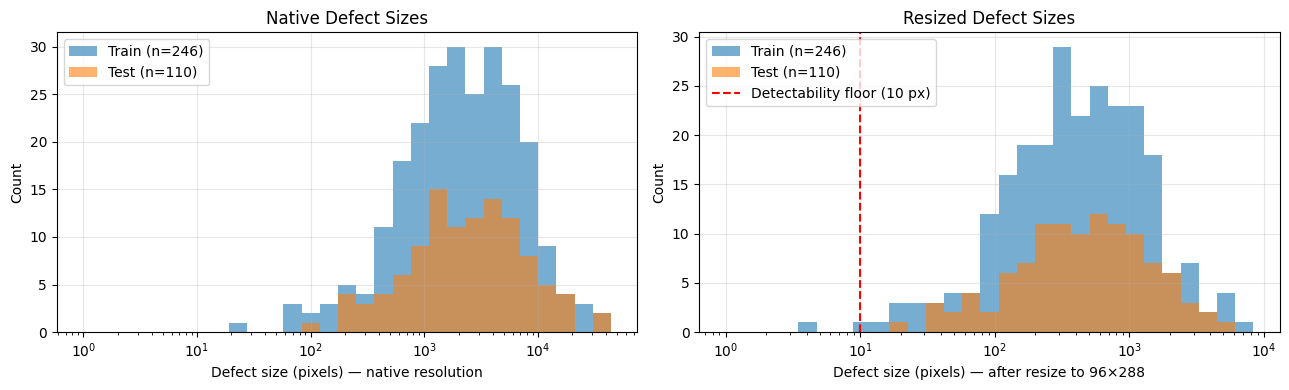

In [ ]:
# Check defect pixel count from masks, native vs. resized resolution
def get_defect_sizes_both(folder):
    native, resized = [], []
    mask_paths = sorted(p for p in folder.glob('*_GT.png'))
    for mp in mask_paths:
        # Native
        mask_native = np.array(Image.open(mp))
        native.append(int((mask_native > 0).sum()))
        # Resized (using same NEAREST interpolation as load_images would on the actual image)
        mask_resized = np.array(Image.open(mp).resize((IMG_W, IMG_H), Image.NEAREST))
        resized.append(int((mask_resized > 0).sum()))
    return np.array(native), np.array(resized)

native_train, resized_train = get_defect_sizes_both(ORGANIZED_DATA_DIR / 'train' / 'damaged')
native_test, resized_test  = get_defect_sizes_both(ORGANIZED_DATA_DIR / 'test'  / 'damaged')

# Combined for overall summary
native_all = np.concatenate([native_train, native_test])
resized_all = np.concatenate([resized_train, resized_test])

# How many defects shrink dramatically or disappear?
THRESHOLD_PIXELS = 10
n_disappear = int((resized_all == 0).sum())
n_below_threshold = int((resized_all < THRESHOLD_PIXELS).sum())

print(f"Native defect sizes  — min={native_all.min()}, median={int(np.median(native_all))}, max={native_all.max()}")
print(f"Resized defect sizes — min={resized_all.min()}, median={int(np.median(resized_all))}, max={resized_all.max()}")
print(f"\nDefects with 0 pixels after resize (lost entirely): {n_disappear} / {len(resized_all)}")
print(f"Defects below {THRESHOLD_PIXELS} pixels after resize: {n_below_threshold} / {len(resized_all)}")

# Plot side-by-side histograms (log scale because sizes span orders of magnitude)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins_native = np.logspace(0, np.log10(native_all.max()), 30)
axes[0].hist(native_train, bins=bins_native, alpha=0.6, label=f'Train (n={len(native_train)})')
axes[0].hist(native_test,  bins=bins_native, alpha=0.6, label=f'Test (n={len(native_test)})')
axes[0].set_xscale('log')
axes[0].set_xlabel('Defect size (pixels) — native resolution')
axes[0].set_ylabel('Count')
axes[0].set_title('Native Defect Sizes')
axes[0].legend()
axes[0].grid(alpha=0.3)

bins_resized = np.logspace(0, np.log10(max(resized_all.max(), 1)), 30)
axes[1].hist(resized_train, bins=bins_resized, alpha=0.6, label=f'Train (n={len(resized_train)})')
axes[1].hist(resized_test,  bins=bins_resized, alpha=0.6, label=f'Test (n={len(resized_test)})')
axes[1].axvline(THRESHOLD_PIXELS, color='red', linestyle='--',
                label=f'Detectability floor ({THRESHOLD_PIXELS} px)')
axes[1].set_xscale('log')
axes[1].set_xlabel(f'Defect size (pixels) — after resize to {IMG_W}×{IMG_H}')
axes[1].set_ylabel('Count')
axes[1].set_title('Resized Defect Sizes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

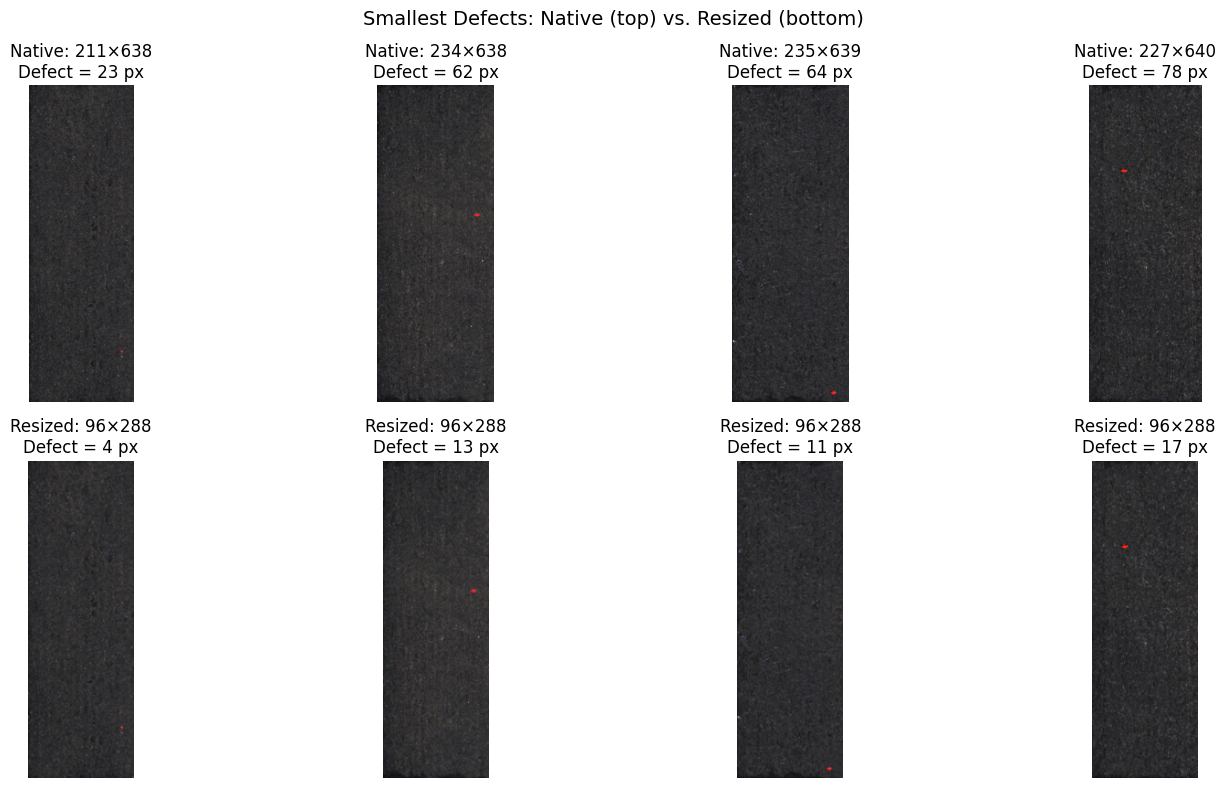

In [ ]:
# Visual check: show the 4 smallest training defects, native vs. resized, with mask overlays

def load_image_and_mask(image_path):
    mask_path = image_path.parent / (image_path.stem + '_GT.png')
    img_native = np.array(Image.open(image_path).convert('RGB'))
    mask_native = np.array(Image.open(mask_path))
    img_resized = np.array(Image.open(image_path).convert('RGB').resize((IMG_W, IMG_H)))
    mask_resized = np.array(Image.open(mask_path).resize((IMG_W, IMG_H), Image.NEAREST))
    return img_native, mask_native, img_resized, mask_resized

# Find the 4 smallest defects in the training set
train_defect_dir = ORGANIZED_DATA_DIR / 'train' / 'damaged'
train_defect_paths = sorted(p for p in train_defect_dir.glob('*.png') if not p.stem.endswith('_GT'))

defect_pixel_counts = []
for p in train_defect_paths:
    mask_path = p.parent / (p.stem + '_GT.png')
    if mask_path.exists():
        mask = np.array(Image.open(mask_path))
        defect_pixel_counts.append((int((mask > 0).sum()), p))

defect_pixel_counts.sort()
smallest_4 = defect_pixel_counts[:4]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (size, path) in enumerate(smallest_4):
    img_n, mask_n, img_r, mask_r = load_image_and_mask(path)

    # Top row: native with mask overlay
    axes[0, i].imshow(img_n)
    axes[0, i].imshow(np.ma.masked_where(mask_n == 0, mask_n), cmap='autumn', alpha=0.7)
    axes[0, i].set_title(f'Native: {img_n.shape[1]}×{img_n.shape[0]}\nDefect = {size} px')
    axes[0, i].axis('off')

    # Bottom row: resized with resized mask overlay
    resized_size = int((mask_r > 0).sum())
    axes[1, i].imshow(img_r)
    axes[1, i].imshow(np.ma.masked_where(mask_r == 0, mask_r), cmap='autumn', alpha=0.7)
    axes[1, i].set_title(f'Resized: {IMG_W}×{IMG_H}\nDefect = {resized_size} px')
    axes[1, i].axis('off')

plt.suptitle('Smallest Defects: Native (top) vs. Resized (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

##Loading and Prepprocessing

Single loader that reads images from a folder, resizes to 288x96, normalizes to [0,1], and returns arrays ready for both supervised and unsupervised pipelines.

In [ ]:
# Unified loader: read all PNGs from folder (excluding _GT masks), resize to (H,W,3), scale to [0,1]

def load_images(folder):
    paths = sorted(p for p in folder.glob('*.png') if not p.stem.endswith('_GT'))
    images = []
    for p in paths:
        img = Image.open(p).convert('RGB').resize((IMG_W, IMG_H))
        images.append(np.array(img, dtype=np.float32) / 255.0)
    return np.array(images) if images else np.zeros((0, IMG_H, IMG_W, 3), dtype=np.float32), paths

# Load all data
X_train_normal, paths_train_normal     = load_images(TRAIN_DIR / 'non_damaged')
X_train_damaged, paths_train_damaged   = load_images(TRAIN_DIR / 'damaged')
X_test_normal, paths_test_normal       = load_images(TEST_DIR / 'non_damaged')
X_test_damaged, paths_test_damaged     = load_images(TEST_DIR / 'damaged')

print(f"Train normal:  {len(X_train_normal)}")
print(f"Train damaged: {len(X_train_damaged)}")
print(f"Test normal:   {len(X_test_normal)}")
print(f"Test damaged:  {len(X_test_damaged)}")
print(f"Total:         {len(X_train_normal)+len(X_train_damaged)+len(X_test_normal)+len(X_test_damaged)}")
print(f"\nImage shape: {X_train_normal[0].shape}")
print(f"Pixel range:  [{X_train_normal.min():.2f}, {X_train_normal.max():.2f}]")

Train normal:  2085
Train damaged: 246
Test normal:   894
Test damaged:  110
Total:         3335

Image shape: (288, 96, 3)
Pixel range:  [0.00, 1.00]


## Data Validation

Sanity checks before modeling: confirm shapes and channel counts, verify each defect image has a paired GT mask, and view a few samples per class.

In [ ]:
# Verify shapes and channels
expected_shape = (IMG_H, IMG_W, 3)

for name, arr in [('train_normal', X_train_normal), ('train_damaged', X_train_damaged),
                  ('test_normal', X_test_normal), ('test_damaged', X_test_damaged)]:
    bad = [i for i in range(len(arr)) if arr[i].shape != expected_shape]
    print(f"{name}: {len(arr)} images, bad shapes: {len(bad)}")

# Check if RGB channels are identical (grayscale stored as RGB)
sample = X_train_normal[0]
print(f"\nChannel check (first train normal):")
print(f"  R==G: {np.allclose(sample[:,:,0], sample[:,:,1])}")
print(f"  R==B: {np.allclose(sample[:,:,0], sample[:,:,2])}")

train_normal: 2085 images, bad shapes: 0
train_damaged: 246 images, bad shapes: 0
test_normal: 894 images, bad shapes: 0
test_damaged: 110 images, bad shapes: 0

Channel check (first train normal):
  R==G: False
  R==B: False


In [ ]:
# Verify mask pairing
def count_masks(folder):
    masks = sorted(p for p in folder.glob('*.png') if p.stem.endswith('_GT'))
    return len(masks)

for split_name, split_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    for cls in ['non_damaged', 'damaged']:
        folder = split_dir / cls
        n_imgs = len([p for p in folder.glob('*.png') if not p.stem.endswith('_GT')])
        n_masks = count_masks(folder)
        print(f"{split_name}/{cls}: {n_imgs} images, {n_masks} masks")

train/non_damaged: 2085 images, 2085 masks
train/damaged: 246 images, 246 masks
test/non_damaged: 894 images, 894 masks
test/damaged: 110 images, 110 masks


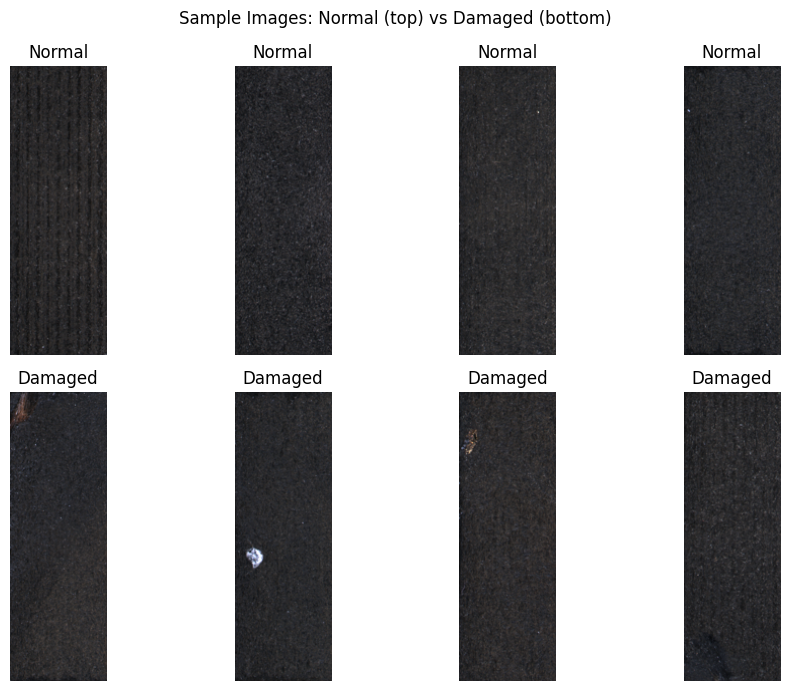

In [ ]:
# Sample images per class
fig, axes = plt.subplots(2, 4, figsize=(10, 7))

for i in range(4):
    axes[0, i].imshow(X_train_normal[i * 50])
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

for i in range(4):
    idx = min(i * 20, len(X_train_damaged) - 1)
    axes[1, i].imshow(X_train_damaged[idx])
    axes[1, i].set_title('Damaged')
    axes[1, i].axis('off')

plt.suptitle('Sample Images: Normal (top) vs Damaged (bottom)')
plt.tight_layout()
plt.show()

## Train / Validation / Test Split

Stratified 80/20 split of the training data, done once and used by all models. Supervised sets keep both classes, unsupervised sets are the same split with defects removed so they stay a strict subset. The test set is locked until final evaluation.

In [ ]:
# Create unified split (stratified 80/20)

# Combine all training data
X_all_train = np.concatenate([X_train_normal, X_train_damaged])
y_all_train = np.array([0]*len(X_train_normal) + [1]*len(X_train_damaged))

# Stratified 80/20 split preserving class ratio
X_train_sup, X_val_sup, y_train_sup, y_val_sup = train_test_split(
    X_all_train, y_all_train,
    test_size=0.20, random_state=SEED, stratify=y_all_train
)

# Unsupervised views: same splits with defects removed
X_train_unsup = X_train_sup[y_train_sup == 0]
X_val_unsup   = X_val_sup[y_val_sup == 0]

# Aliases for backward compatibility
X_train_fit    = X_train_unsup      # normals for PCA/CAE fitting
X_val_normal   = X_val_unsup        # normals for unsupervised validation
X_train_defects = X_train_sup[y_train_sup == 1]  # defects in train split
X_val_defects   = X_val_sup[y_val_sup == 1]      # defects in val split

# Test set (locked)
X_test = np.concatenate([X_test_normal, X_test_damaged])
y_test = np.array([0]*len(X_test_normal) + [1]*len(X_test_damaged))

print("=== Data Split (Stratified 80/20) ===")
print(f"Train total:          {len(X_train_sup)} ({(y_train_sup==1).sum()} defects, {(y_train_sup==0).sum()} normals)")
print(f"Val total:            {len(X_val_sup)} ({(y_val_sup==1).sum()} defects, {(y_val_sup==0).sum()} normals)")
print(f"Train unsupervised:   {len(X_train_unsup)} (normals only)")
print(f"Val unsupervised:     {len(X_val_unsup)} (normals only)")
print(f"Train defects:        {len(X_train_defects)}")
print(f"Val defects:          {len(X_val_defects)}")
print(f"Test set (LOCKED):    {len(X_test)} ({(y_test==1).sum()} defects)")


=== Data Split (Stratified 80/20) ===
Train total:          1864 (197 defects, 1667 normals)
Val total:            467 (49 defects, 418 normals)
Train unsupervised:   1667 (normals only)
Val unsupervised:     418 (normals only)
Train defects:        197
Val defects:          49
Test set (LOCKED):    1004 (110 defects)


In [ ]:
# Create results folder
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

In [ ]:
# Verify normalization
print(f"X_train_fit  — shape: {X_train_fit.shape}, range: [{X_train_fit.min():.3f}, {X_train_fit.max():.3f}]")
print(f"X_val_normal — shape: {X_val_normal.shape}, range: [{X_val_normal.min():.3f}, {X_val_normal.max():.3f}]")
print(f"X_test       — shape: {X_test.shape}, range: [{X_test.min():.3f}, {X_test.max():.3f}]")

X_train_fit  — shape: (1667, 288, 96, 3), range: [0.000, 1.000]
X_val_normal — shape: (418, 288, 96, 3), range: [0.004, 0.910]
X_test       — shape: (1004, 288, 96, 3), range: [0.000, 1.000]


## EDA (Post-Split)

Three checks on the actual splits we will train on: class balance per split, defect size distribution, and pixel intensity distributions. Confirms the split did not introduce drift.

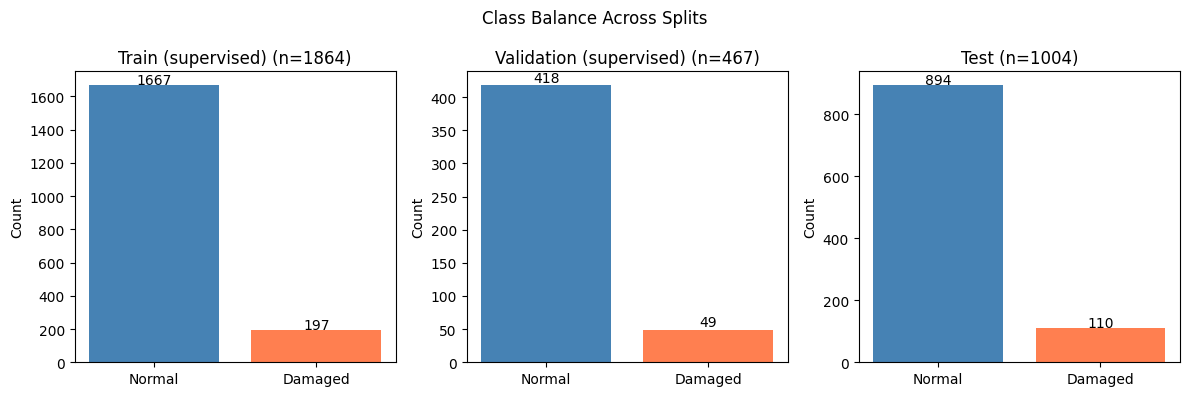

Defect rate — train: 10.6%
Defect rate — val:   10.5%
Defect rate — test:  11.0%


In [ ]:
# Class balance per split
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

splits_data = [
    ('Train (supervised)', len(X_train_fit), len(X_train_defects)),
    ('Validation (supervised)', len(X_val_normal), len(X_val_defects)),
    ('Test', int((y_test==0).sum()), int((y_test==1).sum()))
]

for ax, (name, n_normal, n_damaged) in zip(axes, splits_data):
    bars = ax.bar(['Normal', 'Damaged'], [n_normal, n_damaged], color=['steelblue', 'coral'])
    ax.set_title(f'{name} (n={n_normal+n_damaged})')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', fontsize=10)

plt.suptitle('Class Balance Across Splits')
plt.tight_layout()
plt.show()

print(f"Defect rate — train: {len(X_train_defects)/(len(X_train_fit)+len(X_train_defects))*100:.1f}%")
print(f"Defect rate — val:   {len(X_val_defects)/(len(X_val_normal)+len(X_val_defects))*100:.1f}%")
print(f"Defect rate — test:  {(y_test==1).sum()/len(y_test)*100:.1f}%")

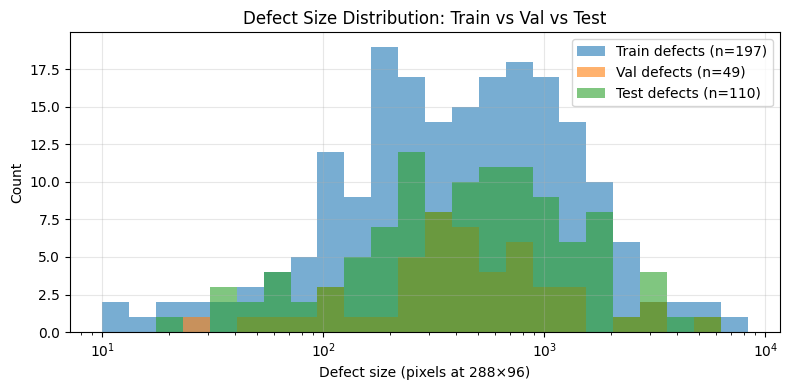

Train defect sizes — min: 4, median: 423, mean: 751, max: 8258
Val defect sizes   — min: 30, median: 419, mean: 730, max: 5980
Test defect sizes  — min: 18, median: 458, mean: 844, max: 8330


In [ ]:
# Defect size distribution from GT masks
def get_defect_sizes(paths):
    sizes = []
    for p in paths:
        mask_path = p.parent / (p.stem + '_GT.png')
        if mask_path.exists():
            mask = np.array(Image.open(mask_path).resize((IMG_W, IMG_H), Image.NEAREST))
            sizes.append(int((mask > 0).sum()))
    return np.array(sizes)

# Recover which defect paths landed in train vs val (same SEED → same shuffle)
paths_all_train = paths_train_normal + paths_train_damaged
_, _, y_train_chk, y_val_chk, paths_train_sup, paths_val_sup = train_test_split(
    X_all_train, y_all_train, paths_all_train,
    test_size=0.20, random_state=SEED, stratify=y_all_train
)
paths_train_defects = [p for p, y in zip(paths_train_sup, y_train_chk) if y == 1]
paths_val_defects   = [p for p, y in zip(paths_val_sup,   y_val_chk)   if y == 1]

train_defect_sizes = get_defect_sizes(paths_train_defects)
val_defect_sizes   = get_defect_sizes(paths_val_defects)
test_defect_sizes  = get_defect_sizes(paths_test_damaged)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(1, np.log10(max(train_defect_sizes.max(), val_defect_sizes.max(), test_defect_sizes.max())), 25)
ax.hist(train_defect_sizes, bins=bins, alpha=0.6, label=f'Train defects (n={len(train_defect_sizes)})')
ax.hist(val_defect_sizes,   bins=bins, alpha=0.6, label=f'Val defects (n={len(val_defect_sizes)})')
ax.hist(test_defect_sizes,  bins=bins, alpha=0.6, label=f'Test defects (n={len(test_defect_sizes)})')
ax.set_xscale('log')
ax.set_xlabel('Defect size (pixels at 288×96)')
ax.set_ylabel('Count')
ax.set_title('Defect Size Distribution: Train vs Val vs Test')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Train defect sizes — min: {train_defect_sizes.min()}, median: {int(np.median(train_defect_sizes))}, "
      f"mean: {train_defect_sizes.mean():.0f}, max: {train_defect_sizes.max()}")
print(f"Val defect sizes   — min: {val_defect_sizes.min()}, median: {int(np.median(val_defect_sizes))}, "
      f"mean: {val_defect_sizes.mean():.0f}, max: {val_defect_sizes.max()}")
print(f"Test defect sizes  — min: {test_defect_sizes.min()}, median: {int(np.median(test_defect_sizes))}, "
      f"mean: {test_defect_sizes.mean():.0f}, max: {test_defect_sizes.max()}")

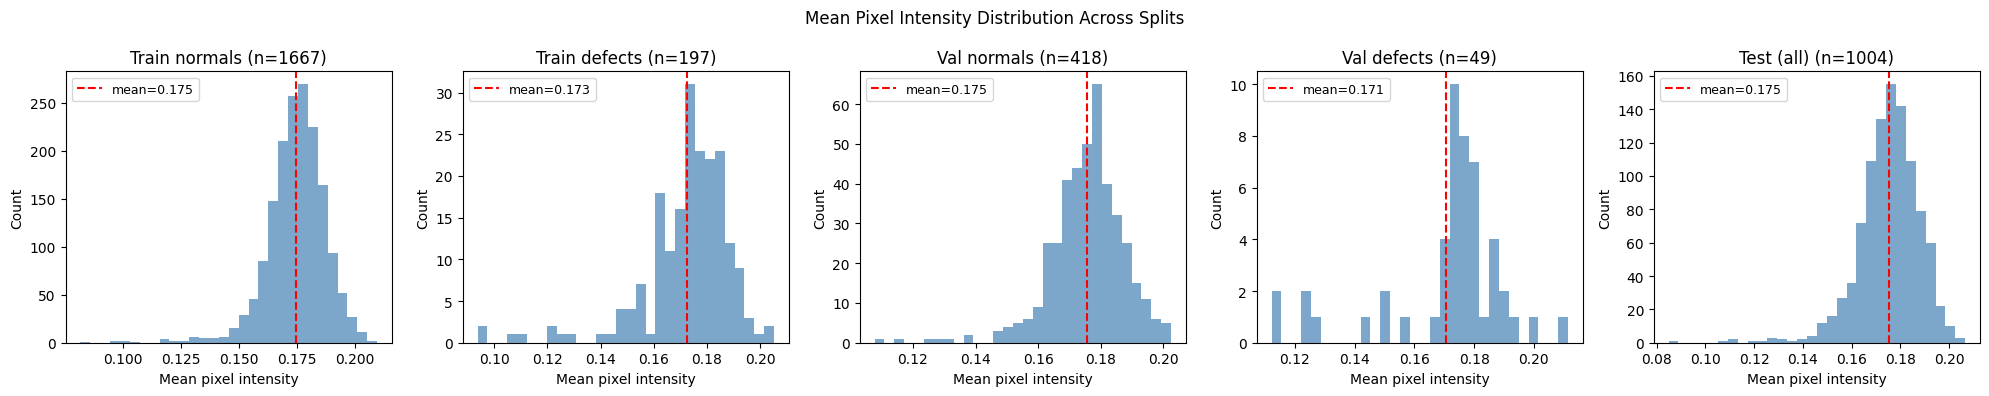

In [ ]:
# Pixel intensity distributions per split
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, data) in zip(axes, [
    ('Train normals', X_train_fit),
    ('Train defects', X_train_defects),
    ('Val normals',   X_val_normal),
    ('Val defects',   X_val_defects),
    ('Test (all)',    X_test)
]):
    mean_per_image = data.mean(axis=(1, 2, 3))
    ax.hist(mean_per_image, bins=30, alpha=0.7, color='steelblue')
    ax.set_xlabel('Mean pixel intensity')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} (n={len(data)})')
    ax.axvline(mean_per_image.mean(), color='red', linestyle='--', label=f'mean={mean_per_image.mean():.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Mean Pixel Intensity Distribution Across Splits')
plt.tight_layout()
plt.show()

## Unsupervised Method 1: PCA Reconstruction Error

PCA is trained on flattened, standardized normal images only, with the anomaly score being the mean squared reconstruction error so higher error means more likely defective. Before fitting we check per-pixel intensity variance, since PCA chases variance by construction and high-variance pixels would otherwise dominate the first components.

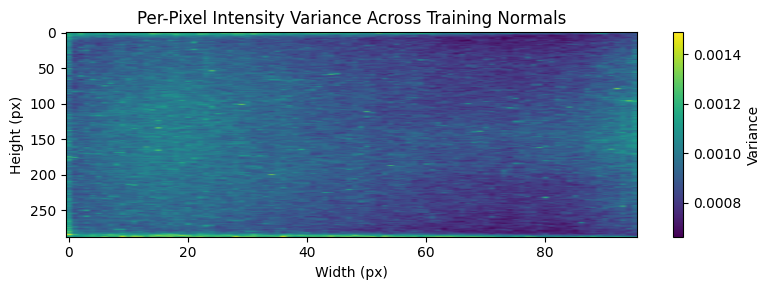

Variance range: [0.00066, 0.00149]
Variance ratio (max/min): 2.2×


In [ ]:
# Per-pixel variance heatmap (train normals)
pixel_variance = X_train_unsup.var(axis=0).mean(axis=-1)  # (H, W), averaged over RGB channels

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pixel_variance, cmap='viridis', aspect='auto')
ax.set_title('Per-Pixel Intensity Variance Across Training Normals')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
plt.colorbar(im, ax=ax, label='Variance')
plt.tight_layout()
plt.show()

print(f"Variance range: [{pixel_variance.min():.5f}, {pixel_variance.max():.5f}]")
print(f"Variance ratio (max/min): {pixel_variance.max()/pixel_variance.min():.1f}×")

In [ ]:
# Flatten and standardize (train normals only)
n_features = IMG_H * IMG_W * 3
print(f"Each image becomes a vector of length {IMG_H}×{IMG_W}×3 = {n_features}")

X_train_flat = X_train_unsup.reshape(len(X_train_unsup), n_features)
X_val_unsup_flat = X_val_unsup.reshape(len(X_val_unsup), n_features)
X_test_flat = X_test.reshape(len(X_test), n_features)

# Standardize using training normals stats only
pca_mean = X_train_flat.mean(axis=0)
pca_std  = X_train_flat.std(axis=0) + 1e-8

X_train_centered = (X_train_flat - pca_mean) / pca_std
X_val_centered   = (X_val_unsup_flat - pca_mean) / pca_std
X_test_centered  = (X_test_flat - pca_mean) / pca_std

print(f"Standardized train: mean={X_train_centered.mean():.6f}, std={X_train_centered.std():.4f}")


Each image becomes a vector of length 288×96×3 = 82944
Standardized train: mean=0.000035, std=1.0000


  var=0.05 → K=   1  val_loss=0.819382  (41.0s)
  var=0.10 → K=   1  val_loss=0.819382  (43.0s)
  var=0.15 → K=   1  val_loss=0.819382  (44.2s)
  var=0.20 → K=   2  val_loss=0.799601  (50.2s)
  var=0.25 → K=   8  val_loss=0.760609  (41.4s)
  var=0.30 → K=  39  val_loss=0.738194  (41.8s)
  var=0.50 → K= 307  val_loss=0.711691  (47.0s)
  var=0.70 → K= 690  val_loss=0.686731  (43.9s)
  var=0.90 → K=1246  val_loss=0.658022  (43.5s)

Elbow detected at var_threshold=0.3
  n_components=39, val_recon_loss=0.738194


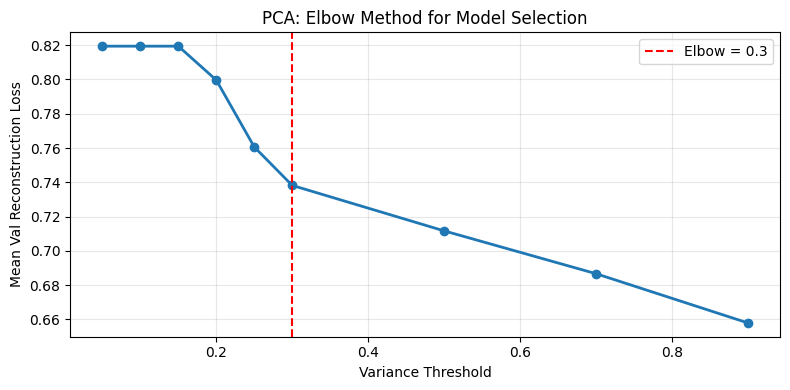

In [ ]:
# PCA variance threshold sweep (fully unsupervised)

def reconstruction_error(X_centered, pca_model):
    Z = pca_model.transform(X_centered)
    X_hat = pca_model.inverse_transform(Z)
    return ((X_centered - X_hat) ** 2).mean(axis=1)

thresholds_var = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50, 0.70, 0.90]
sweep_results_pca = []

for var_t in thresholds_var:
    t0 = time.time()
    pca_model = PCA(n_components=var_t, random_state=SEED)
    pca_model.fit(X_train_centered)
    fit_time = time.time() - t0

    val_scores = reconstruction_error(X_val_centered, pca_model)
    val_recon_loss = val_scores.mean()

    sweep_results_pca.append({
        'var_threshold': var_t,
        'n_components': pca_model.n_components_,
        'val_recon_loss': val_recon_loss,
        'fit_time_s': fit_time
    })
    print(f"  var={var_t:.2f} → K={pca_model.n_components_:>4d}  val_loss={val_recon_loss:.6f}  ({fit_time:.1f}s)")

pca_sweep_df = pd.DataFrame(sweep_results_pca)

# Elbow method: find the knee in val_recon_loss vs var_threshold
kneedle = KneeLocator(
    pca_sweep_df['var_threshold'].values,
    pca_sweep_df['val_recon_loss'].values,
    curve='convex', direction='decreasing', S=1.0
)

BEST_VAR_THRESHOLD = kneedle.knee
if BEST_VAR_THRESHOLD is None:
    BEST_VAR_THRESHOLD = 0.30
    print(f"WARNING: Knee not detected, defaulting to var_threshold={BEST_VAR_THRESHOLD}")
else:
    print(f"\nElbow detected at var_threshold={BEST_VAR_THRESHOLD}")

best_pca_row = pca_sweep_df[pca_sweep_df["var_threshold"] == BEST_VAR_THRESHOLD].iloc[0]
print(f"  n_components={int(best_pca_row['n_components'])}, val_recon_loss={best_pca_row['val_recon_loss']:.6f}")

# Elbow visualization
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_sweep_df['var_threshold'], pca_sweep_df['val_recon_loss'], 'o-', linewidth=2)
ax.axvline(BEST_VAR_THRESHOLD, color="red", linestyle="--", label=f"Elbow = {BEST_VAR_THRESHOLD}")
ax.set_xlabel('Variance Threshold')
ax.set_ylabel('Mean Val Reconstruction Loss')
ax.set_title('PCA: Elbow Method for Model Selection')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Final PCA: K=39 components, var_threshold=0.3


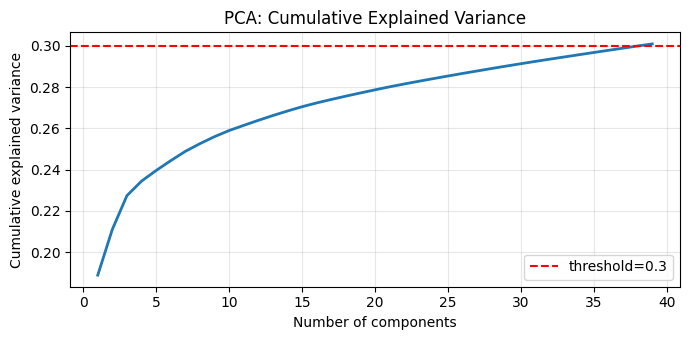

In [ ]:
# Fit final PCA with best threshold

t0 = time.time()
pca_final = PCA(n_components=BEST_VAR_THRESHOLD, random_state=SEED)
pca_final.fit(X_train_centered)
pca_fit_time = time.time() - t0

print(f"Final PCA: K={pca_final.n_components_} components, var_threshold={BEST_VAR_THRESHOLD}")

# Cumulative explained variance
cum_var = np.cumsum(pca_final.explained_variance_ratio_)
plt.figure(figsize=(7, 3.5))
plt.plot(np.arange(1, pca_final.n_components_ + 1), cum_var, lw=2)
plt.axhline(BEST_VAR_THRESHOLD, color='r', linestyle='--', label=f'threshold={BEST_VAR_THRESHOLD}')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


  PCA p90 threshold: 0.885989
  PCA p95 threshold: 0.944147
  PCA p99 threshold: 1.166710


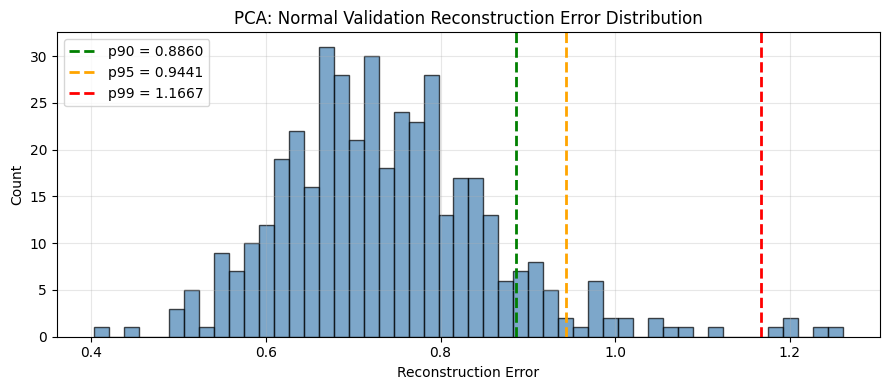

In [ ]:
# PCA threshold selection: p-quartile approach
pca_val_scores = reconstruction_error(X_val_centered, pca_final)

# Compute thresholds at 90th, 95th, 99th percentile of normal val scores
pca_thresholds = {}
for q in [90, 95, 99]:
    pca_thresholds[q] = np.percentile(pca_val_scores, q)
    print(f"  PCA p{q} threshold: {pca_thresholds[q]:.6f}")

# Histogram of normal val reconstruction errors with quartile lines
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pca_val_scores, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
colors = {90: 'green', 95: 'orange', 99: 'red'}
for q, thresh in pca_thresholds.items():
    ax.axvline(thresh, color=colors[q], linestyle="--", linewidth=2,
              label=f"p{q} = {thresh:.4f}")
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Count')
ax.set_title('PCA: Normal Validation Reconstruction Error Distribution')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# PCA threshold selection after inspecting the histogram
PCA_QUARTILE = 95
pca_threshold = pca_thresholds[PCA_QUARTILE]
print(f"Selected PCA threshold: p{PCA_QUARTILE} = {pca_threshold:.6f}")

Selected PCA threshold: p95 = 0.944147


### Save checkpoint: PCA

In [ ]:
# Save PCA results
pd.DataFrame({
    'split': ['val']*len(pca_val_scores),
    'score': pca_val_scores,
    'label': np.zeros(len(pca_val_scores), dtype=int),
}).to_csv(RESULTS_DIR / 'pca_scores.csv', index=False)

pd.DataFrame([{
    'model': 'PCA',
    'n_components': pca_final.n_components_,
    'var_threshold': BEST_VAR_THRESHOLD,
    'val_recon_loss': pca_val_scores.mean(),
    'threshold': pca_threshold,
    'train_time_s': pca_fit_time,
}]).to_csv(RESULTS_DIR / 'pca_metrics.csv', index=False)
print("Saved: pca_scores.csv, pca_metrics.csv")


Saved: pca_scores.csv, pca_metrics.csv


## Convolutional Autoencoder (CAE)

The CAE is trained to reconstruct normal images only, so defective images produce higher reconstruction error at inference since the model never learned to reproduce defect patterns. The table below lists the baseline design choices used before the hyperparameter sweep.

### Baseline Setup

| # | Choice | Value |
|---|---|---|
| 1 | Encoder blocks | 4 (288x96 to 18x6 bottleneck) |
| 2 | Decoder blocks | 4, mirrored |
| 3 | Channel progression | 32, 64, 128, 256 |
| 4 | Bottleneck | 1x1 Conv to latent_channels |
| 5 | Decoder upsampling | Conv2DTranspose stride=2 |
| 6 | Skip connections | None |
| 7 | Output activation | Sigmoid |
| 8 | Loss | MSE |
| 9 | Optimizer | Adam, lr=1e-3 |
| 10 | Anomaly score | Global MSE |
| 11 | Batch normalisation | After each Conv layer |
| 12 | Early stopping | patience=10 on val recon loss |

In [ ]:
# Build CAE
def build_cae(latent_channels=8, input_shape=(IMG_H, IMG_W, 3)):
    inp = layers.Input(shape=input_shape)

    # Encoder: 4 blocks of Conv -> BN -> ReLU -> MaxPool
    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    # Bottleneck: 1x1 conv to compress channels
    x = layers.Conv2D(latent_channels, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder: 4 blocks of Conv2DTranspose -> BN -> ReLU
    x = layers.Conv2DTranspose(256, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    out = layers.Conv2D(3, 1, padding='same', activation='sigmoid')(x)

    return keras.Model(inp, out, name=f'cae_latent{latent_channels}')

cae_baseline = build_cae(latent_channels=8)
cae_baseline.summary()

Model: "cae_latent8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 288, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 288, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 288, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 288, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 144, 48, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 144, 48, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 144, 48, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 144, 48, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 72, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 72, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 72, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 36, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 36, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 36, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 36, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 6, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 6, 8)       │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 18, 6, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 18, 6, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 36, 12, 256)    │        18,688 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 36, 12, 256)    │         1,02

 Total params: 800,427 (3.05 MB)

 Trainable params: 798,491 (3.05 MB)

 Non-trainable params: 1,936 (7.56 KB)

In [ ]:
# Compile and train baseline CAE
cae_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

cae_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

t0 = time.time()
history_cae = cae_baseline.fit(
    X_train_fit, X_train_fit,
    validation_data=(X_val_normal, X_val_normal),
    epochs=100,
    batch_size=32,
    callbacks=[cae_early_stop],
    verbose=1
)
cae_baseline_time = time.time() - t0
print(f"\nTraining time: {cae_baseline_time:.1f}s")
print(f"Best epoch: {np.argmin(history_cae.history['val_loss']) + 1}")

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 100s 859ms/step - loss: 0.0462 - val_loss: 0.0630
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0123 - val_loss: 0.0260
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0060 - val_loss: 0.0078
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0047 - val_loss: 0.0026
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0042 - val_loss: 0.0013
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0031 - val_loss: 0.0014
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0023 - val_loss: 0.0033
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0018 - val_loss: 0.0026
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/s

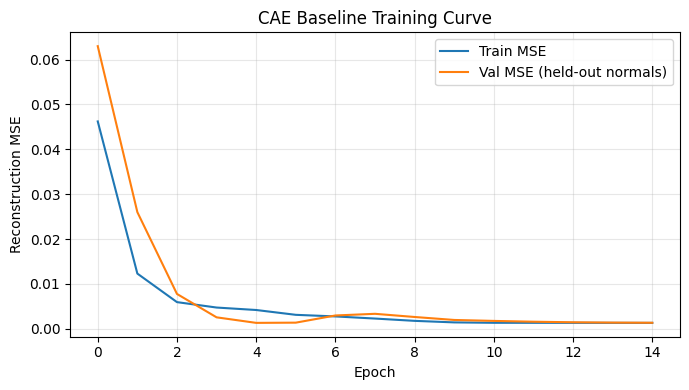

In [ ]:
# Training curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_cae.history['loss'], label='Train MSE')
ax.plot(history_cae.history['val_loss'], label='Val MSE (held-out normals)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('CAE Baseline Training Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Dead ReLU check
# Pass a batch of training images through the encoder and check for dead neurons
sample_batch = X_train_fit[:64]

for layer in cae_baseline.layers:
    if isinstance(layer, layers.ReLU):
        # Build a temporary model up to this layer
        temp_model = keras.Model(cae_baseline.input, layer.output)
        activations = temp_model.predict(sample_batch, verbose=0)

        # A neuron is "dead" if it outputs 0 for every image in the batch
        if len(activations.shape) == 4:  # Conv layer: (batch, H, W, channels)
            dead_frac = (activations.max(axis=(0, 1, 2)) == 0).mean()
        else:
            dead_frac = (activations.max(axis=0) == 0).mean()

        print(f"{layer.name:>20s}: {dead_frac*100:.1f}% dead neurons")

               re_lu: 0.0% dead neurons
             re_lu_1: 3.1% dead neurons
             re_lu_2: 15.6% dead neurons
             re_lu_3: 8.6% dead neurons
             re_lu_4: 0.0% dead neurons
             re_lu_5: 0.0% dead neurons
             re_lu_6: 3.1% dead neurons
             re_lu_7: 15.6% dead neurons
             re_lu_8: 0.0% dead neurons


In [ ]:
# Anomaly scoring function: global MSE per image (mean of all pixel errors)

def anomaly_scores_cae(model, images, batch_size=32):
    recon = model.predict(images, batch_size=batch_size, verbose=0)
    err = ((images - recon) ** 2).mean(axis=-1)  # per-pixel squared error, averaged across channels
    return err.mean(axis=(1, 2))  # average across all pixels -> one score per image

In [ ]:
# Baseline CAE evaluation (validation only)
cae_bl_val_scores = anomaly_scores_cae(cae_baseline, X_val_normal)

print(f"CAE Baseline Validation Results (normals only):")
print(f"  Mean recon error: {cae_bl_val_scores.mean():.6f}")
print(f"  Std recon error:  {cae_bl_val_scores.std():.6f}")


CAE Baseline Validation Results (normals only):
  Mean recon error: 0.001330
  Std recon error:  0.000725


### Baseline Diagnostics

Before running the sweeps, we examine the baseline model's behaviour on the validation set to motivate our hyperparameter search.

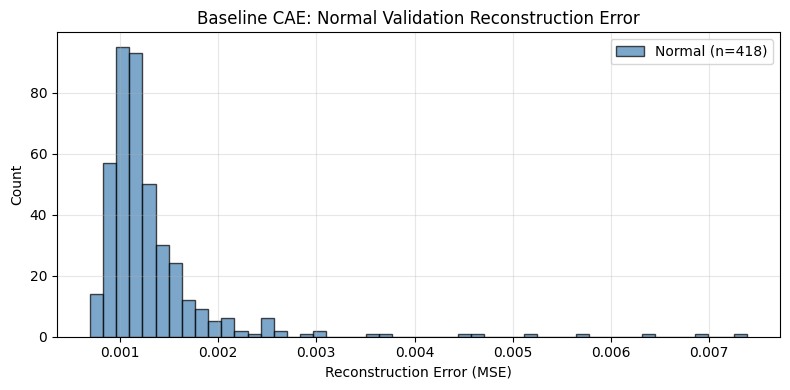

Normal recon error: mean=0.001330  std=0.000725


In [ ]:
# Diagnostic 1: normal reconstruction error distribution
recon_val = cae_baseline.predict(X_val_normal, batch_size=32, verbose=0)
recon_err = ((X_val_normal - recon_val) ** 2).mean(axis=(1, 2, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recon_err, bins=50, alpha=0.7, edgecolor='black', color='steelblue',
        label=f"Normal (n={len(recon_err)})")
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Count')
ax.set_title('Baseline CAE: Normal Validation Reconstruction Error')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Normal recon error: mean={recon_err.mean():.6f}  std={recon_err.std():.6f}")


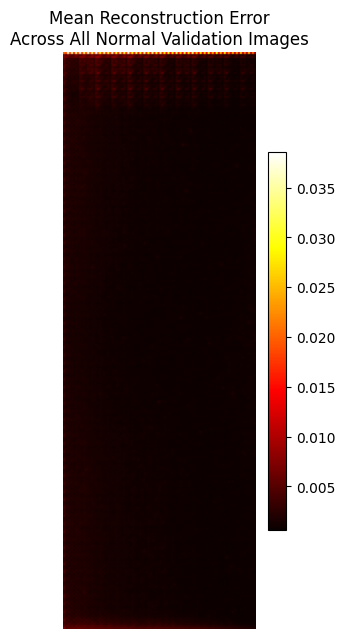

Min: 0.000648
Max: 0.038612
Mean: 0.001330
Std: 0.001503


In [ ]:
# Diagnostic 2: mean normal error heatmap (motivates Sweep C)
recon_normals = cae_baseline.predict(X_val_normal, batch_size=32, verbose=0)
err_normals = ((X_val_normal - recon_normals) ** 2).mean(axis=-1)
mean_err_map = err_normals.mean(axis=0)

fig, ax = plt.subplots(figsize=(3, 8))
im = ax.imshow(mean_err_map, cmap='hot')
ax.set_title('Mean Reconstruction Error\nAcross All Normal Validation Images')
ax.axis('off')
plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()
plt.show()

print(f"Min: {mean_err_map.min():.6f}")
print(f"Max: {mean_err_map.max():.6f}")
print(f"Mean: {mean_err_map.mean():.6f}")
print(f"Std: {mean_err_map.std():.6f}")

# Check if high-error pixels are at fixed locations - Move to the discussion in the appendix
# top_mask = mean_err_map > np.percentile(mean_err_map, 99.5)
# print(f"Number of extreme pixels: {top_mask.sum()}")
# print(f"Locations (row, col):")
# print(np.argwhere(top_mask))

### CAE Hyperparameter Sweep (Fully Unsupervised)

Sequential coordinate-wise search, with each stage building on the best result from the previous.

=== Bottleneck Sweep ===
  latent= 2  val_loss=0.000657  params=785,037  time=125.1s  best_epoch=32
  latent= 4  val_loss=0.000631  params=790,167  time=137.6s  best_epoch=38
  latent= 6  val_loss=0.000609  params=795,297  time=166.7s  best_epoch=49
  latent= 8  val_loss=0.000601  params=800,427  time=141.6s  best_epoch=44
  latent=10  val_loss=0.000588  params=805,557  time=260.9s  best_epoch=100
  latent=12  val_loss=0.000585  params=810,687  time=205.3s  best_epoch=65

KneeLocator recommends latent_channels = 6


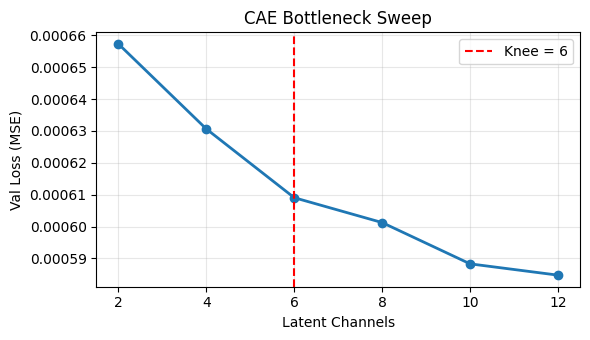


Val loss by latent channels:
 latent_channels  val_loss  n_params  train_time_s
               2  0.000657    785037    125.101491
               4  0.000631    790167    137.619005
               6  0.000609    795297    166.722625
               8  0.000601    800427    141.622621
              10  0.000588    805557    260.903619
              12  0.000585    810687    205.338721


In [ ]:
# Bottleneck sweep
cae_sweep_log = []
cae_models = {}

print("=== Bottleneck Sweep ===")

for lc in [2, 4, 6, 8, 10, 12]:
    tf.keras.utils.set_random_seed(SEED)

    model = build_cae(latent_channels=lc)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

    cb_early = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )

    t0 = time.time()
    hist = model.fit(
        X_train_fit, X_train_fit,
        validation_data=(X_val_normal, X_val_normal),
        epochs=100, batch_size=32,
        callbacks=[cb_early], verbose=0
    )
    train_time = time.time() - t0

    best_val_loss = min(hist.history['val_loss'])
    best_epoch = int(np.argmin(hist.history['val_loss'])) + 1
    run_name = f'latent{lc}'

    cae_sweep_log.append({
        'run_name': run_name,
        'latent_channels': lc,
        'val_loss': best_val_loss,
        'n_params': model.count_params(),
        'train_time_s': train_time,
        'best_epoch': best_epoch,
    })
    cae_models[run_name] = model

    print(f"  latent={lc:>2d}  val_loss={best_val_loss:.6f}  "
          f"params={model.count_params():,}  time={train_time:.1f}s  best_epoch={best_epoch}")

stage_a_df = pd.DataFrame(cae_sweep_log)

# Knee locator on val_loss vs latent_channels
kneedle_cae = KneeLocator(
    stage_a_df['latent_channels'].values,
    stage_a_df['val_loss'].values,
    curve='convex', direction='decreasing', S=0.5
)
knee_latent = int(kneedle_cae.knee) if kneedle_cae.knee is not None else None
print(f"\nKneeLocator recommends latent_channels = {knee_latent}")

# Plot val loss vs latent channels with knee marked
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(stage_a_df['latent_channels'], stage_a_df['val_loss'], 'o-', linewidth=2)
if knee_latent is not None:
    ax.axvline(knee_latent, color='red', linestyle='--', label=f'Knee = {knee_latent}')
    ax.legend()
ax.set_xlabel('Latent Channels')
ax.set_ylabel('Val Loss (MSE)')
ax.set_title('CAE Bottleneck Sweep')
ax.set_xticks(stage_a_df['latent_channels'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVal loss by latent channels:")
print(stage_a_df[['latent_channels', 'val_loss', 'n_params', 'train_time_s']].to_string(index=False))


In [ ]:
# Setting bottleneck based on val loss curve and knee recommendation above
BEST_LATENT = knee_latent

best_cae_model = cae_models[f'latent{BEST_LATENT}']
best_val_loss = stage_a_df.loc[stage_a_df['latent_channels'] == BEST_LATENT, 'val_loss'].values[0]

print(f"Selected latent_channels = {BEST_LATENT}")
print(f"  Val loss: {best_val_loss:.6f}")
print(f"  Params:   {best_cae_model.count_params():,}")


Selected latent_channels = 6
  Val loss: 0.000609
  Params:   795,297


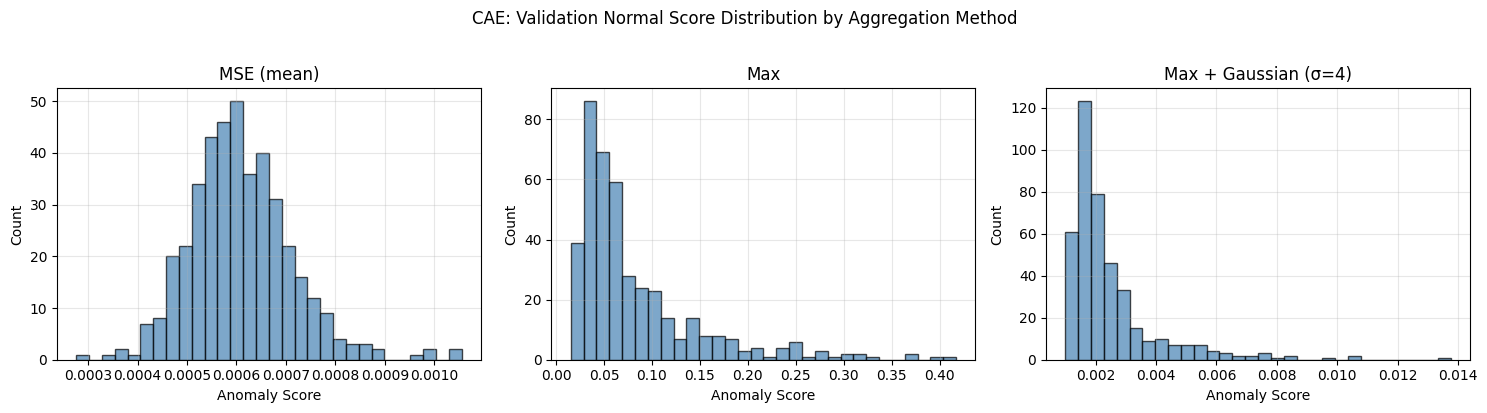


Aggregation method statistics (validation normals):
              method     mean      std
          MSE (mean) 0.000609 0.000104
                 Max 0.082720 0.067741
Max + Gaussian (σ=4) 0.002494 0.001591


In [ ]:
# Comparing Aggregation methods on validation normals set
# Compute per-image anomaly scores using 3 aggregation methods on the same
# reconstruction error maps, then compare distributions.

SIGMA = 4  # Gaussian smoothing sigma for the 'max_smooth' method

recon_val = best_cae_model.predict(X_val_normal, batch_size=32, verbose=0)
err_maps = ((X_val_normal - recon_val) ** 2).mean(axis=-1)   # (N, H, W) per-pixel squared error

agg_scores = {
    'MSE (mean)':            err_maps.mean(axis=(1, 2)),
    'Max':                   err_maps.max(axis=(1, 2)),
    f'Max + Gaussian (σ={SIGMA})': np.array([
        float(gaussian_filter(err_maps[i], sigma=SIGMA).max())
        for i in range(len(err_maps))
    ]),
}

# Plot histograms side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, scores) in zip(axes, agg_scores.items()):
    ax.hist(scores, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_title(name)
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
plt.suptitle('CAE: Validation Normal Score Distribution by Aggregation Method', y=1.02)
plt.tight_layout()
plt.show()

# Report mean and std for each method
agg_summary = pd.DataFrame([
    {'method': name, 'mean': scores.mean(), 'std': scores.std()}
    for name, scores in agg_scores.items()
])
print("\nAggregation method statistics (validation normals):")
print(agg_summary.to_string(index=False))


In [ ]:
# Setting aggregation method based on the histograms and mean/std values above
BEST_AGG = 'max_smooth'   # <-- hardcoded after manual choice; options: 'mse', 'max', 'max_smooth'

print(f"Selected aggregation method: {BEST_AGG}" + (f" (σ={SIGMA})" if BEST_AGG == 'max_smooth' else ""))

Selected aggregation method: max_smooth (σ=4)


In [ ]:
# Overview of choosen config

selected_val_loss = stage_a_df.loc[stage_a_df['latent_channels'] == BEST_LATENT, 'val_loss'].values[0]

print(f"Selected CAE configuration:")
print(f"  Latent channels:     {BEST_LATENT}")
print(f"  Loss:                MSE")
print(f"  Aggregation:         {BEST_AGG}" + (f" (σ={SIGMA})" if BEST_AGG == 'max_smooth' else ""))
print(f"  Val loss:            {selected_val_loss:.6f}")
print(f"  Params:              {best_cae_model.count_params():,}")


Selected CAE configuration:
  Latent channels:     6
  Loss:                MSE
  Aggregation:         max_smooth (σ=4)
  Val loss:            0.000609
  Params:              795,297


  CAE p90 threshold: 0.004327
  CAE p95 threshold: 0.005676
  CAE p99 threshold: 0.008578


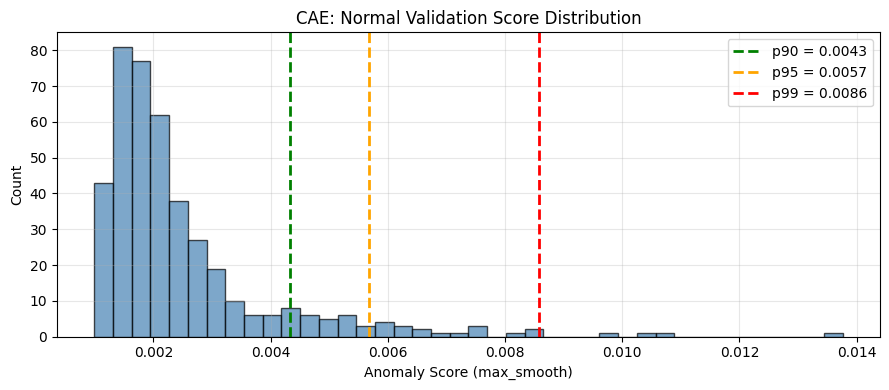

In [ ]:
# Reusable scoring function for threshold selection, test eval, and crossover
# Branches on BEST_AGG so the chosen aggregation method flows downstream.
def score_images(model, images):
    recon = model.predict(images, batch_size=32, verbose=0)
    err = ((images - recon) ** 2).mean(axis=-1)   # (N, H, W) per-pixel squared error

    if BEST_AGG == 'mse':
        return err.mean(axis=(1, 2))
    elif BEST_AGG == 'max':
        return err.max(axis=(1, 2))
    elif BEST_AGG == 'max_smooth':
        return np.array([
            float(gaussian_filter(err[i], sigma=SIGMA).max())
            for i in range(len(err))
        ])
    else:
        raise ValueError(f"Unknown BEST_AGG: {BEST_AGG}")


# CAE threshold selection: p-quartile approach
cae_val_normal_scores = score_images(best_cae_model, X_val_normal)

cae_thresholds = {}
for q in [90, 95, 99]:
    cae_thresholds[q] = np.percentile(cae_val_normal_scores, q)
    print(f"  CAE p{q} threshold: {cae_thresholds[q]:.6f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cae_val_normal_scores, bins=40, alpha=0.7, edgecolor='black', color='steelblue')
colors = {90: 'green', 95: 'orange', 99: 'red'}
for q, thresh in cae_thresholds.items():
    ax.axvline(thresh, color=colors[q], linestyle="--", linewidth=2,
              label=f"p{q} = {thresh:.4f}")
ax.set_xlabel(f'Anomaly Score ({BEST_AGG})')
ax.set_ylabel('Count')
ax.set_title('CAE: Normal Validation Score Distribution')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# CAE threshold selection after inspecting the histogram
CAE_QUARTILE = 95
cae_threshold = cae_thresholds[CAE_QUARTILE]
print(f"Selected CAE threshold: p{CAE_QUARTILE} = {cae_threshold:.6f}")

Selected CAE threshold: p95 = 0.005676


## Supervised Method: CNN

Iterative development from a minimal baseline to an optimized architecture, where each iteration addresses a specific problem observed in the previous model.

| Model | Change | Motivation |
|-------|--------|------------|
| v1 | Minimal CNN | Baseline |
| v2 | Replace Flatten with GlobalMaxPooling2D | Better for localized defects |
| v2_tuned | Keras-tuner (filters, lr, l2, dropout) | Optimize hyperparameters |
| ResNet50 | Transfer learning | Leverage ImageNet features |

In [ ]:
# Shared training settings
INPUT_SHAPE = (IMG_H, IMG_W, 3)
BATCH = 32
CNN_EPOCHS = 50

# Class weights for imbalanced training
n_neg = int((y_train_sup == 0).sum())
n_pos = int((y_train_sup == 1).sum())
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f"Class weight: {{0: 1.0, 1: {class_weight[1]:.2f}}}")

# Results dictionary
cnn_results = {}

Class weight: {0: 1.0, 1: 8.46}


In [ ]:
# Shared evaluation function (validation only)
def evaluate_cnn(model, model_name, history, train_time, cnn_results):
    # Val predictions only (test is reserved for final evaluation)
    val_probs = model.predict(X_val_sup, verbose=0).flatten()

    # Threshold via F1-max on val
    precs, recs, thresholds = precision_recall_curve(y_val_sup, val_probs)
    f1s = 2 * precs * recs / (precs + recs + 1e-9)
    best_idx = f1s[:-1].argmax()
    threshold = thresholds[best_idx]

    # Val metrics
    val_auroc = roc_auc_score(y_val_sup, val_probs)
    val_auprc = average_precision_score(y_val_sup, val_probs)
    val_pred = (val_probs >= threshold).astype(int)
    val_f1 = f1_score(y_val_sup, val_pred)

    cnn_results[model_name] = {
        'val_auroc': val_auroc, 'val_auprc': val_auprc, 'val_f1': val_f1,
        'threshold': threshold, 'train_time_s': train_time,
        'n_params': model.count_params(),
        'model': model  # keep reference for final test evaluation
    }

    print(f"\n[{model_name}]")
    print(f"  Val: AUROC={val_auroc:.4f}, AUPRC={val_auprc:.4f}, F1={val_f1:.4f}")
    print(f"  Threshold={threshold:.4f}, Params={model.count_params():,}, Time={train_time:.1f}s")

    # Learning curves
    if history is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(history.history['loss'], label='Train Loss')
        ax1.plot(history.history['val_loss'], label='Val Loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'{model_name}: Loss'); ax1.legend(); ax1.grid(alpha=0.3)

        if 'auc' in history.history:
            ax2.plot(history.history['auc'], label='Train AUC')
            ax2.plot(history.history['val_auc'], label='Val AUC')
        elif 'ap' in history.history:
            ax2.plot(history.history['ap'], label='Train AP')
            ax2.plot(history.history['val_ap'], label='Val AP')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Metric')
        ax2.set_title(f'{model_name}: AUC/AP'); ax2.legend(); ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return cnn_results[model_name]

### CNN v1: Baseline

Minimal CNN with Flatten before the dense head. Establishes a reference point for parameter count and validation performance.

In [ ]:
# CNN v1: architecture
model_v1 = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 288, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 144, 48, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 144, 48, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 72, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 72, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 221184)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       221,185 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,433 (1.20 MB)

 Trainable params: 314,433 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CNN v1: compile and train
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='ap', curve='PR')]
)

t0 = time.time()
history_v1 = model_v1.fit(
    X_train_sup, y_train_sup,
    validation_data=(X_val_sup, y_val_sup),
    epochs=CNN_EPOCHS, batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_ap', mode='max', patience=8, restore_best_weights=True)
    ],
    verbose=1
)
time_v1 = time.time() - t0

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 292ms/step - ap: 0.0955 - auc: 0.4625 - loss: 1.2878 - val_ap: 0.1049 - val_auc: 0.5000 - val_loss: 0.6942
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - ap: 0.1055 - auc: 0.4931 - loss: 1.2460 - val_ap: 0.1049 - val_auc: 0.5000 - val_loss: 0.6932
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.1342 - auc: 0.5513 - loss: 1.2378 - val_ap: 0.5032 - val_auc: 0.7846 - val_loss: 0.5747
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - ap: 0.1220 - auc: 0.5390 - loss: 1.2825 - val_ap: 0.1329 - val_auc: 0.5102 - val_loss: 0.6937
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - ap: 0.0996 - auc: 0.4884 - loss: 1.2404 - val_ap: 0.1049 - val_auc: 0.5000 - val_loss: 0.6935
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - ap: 0.1053 - auc: 0.5206 - loss: 1.2382 - val_ap: 0.2747 - val_auc: 0.5542 - val_loss: 0.5711
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - ap: 0.1141 - auc: 0.5286 - loss: 1.2611 - val_ap: 0.2596 - val_


[CNN_v1]
  Val: AUROC=0.8279, AUPRC=0.6857, F1=0.6835
  Threshold=0.5332, Params=314,433, Time=40.3s


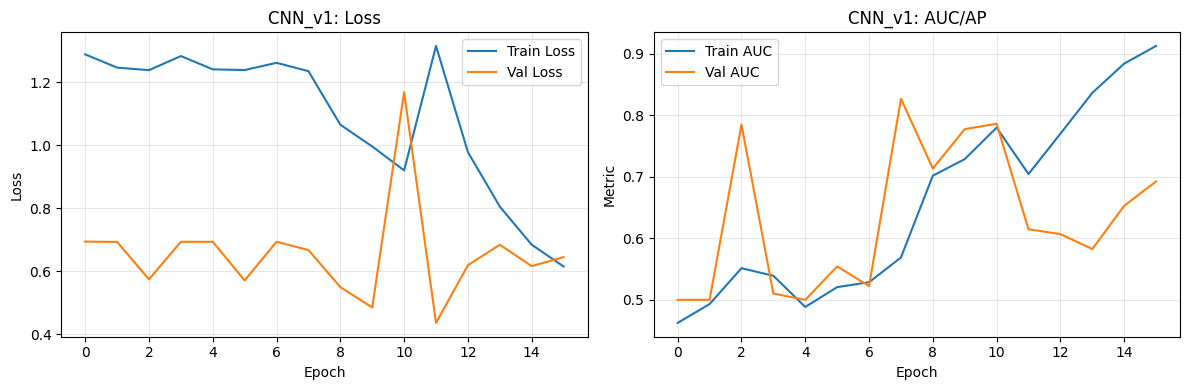

{'val_auroc': 0.8278976662435309,
 'val_auprc': 0.6857304102261313,
 'val_f1': 0.6835443037974683,
 'threshold': np.float32(0.5331608),
 'train_time_s': 40.29946446418762,
 'n_params': 314433,
 'model': <Sequential name=sequential, built=True>}

In [ ]:
# CNN v1: evaluation
evaluate_cnn(model_v1, 'CNN_v1', history_v1, time_v1, cnn_results)

### CNN v2: GlobalMaxPooling2D

Defects are localized so a single hot spot in a feature map should suffice for detection. GlobalMaxPooling takes the maximum activation per channel, discarding spatial information but retaining the strongest signal.

In [ ]:
# CNN v2: architecture
model_v2 = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.GlobalMaxPooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 288, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 144, 48, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 144, 48, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 72, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 72, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CNN v2: compile and train
model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='ap', curve='PR')]
)

t0 = time.time()
history_v2 = model_v2.fit(
    X_train_sup, y_train_sup,
    validation_data=(X_val_sup, y_val_sup),
    epochs=CNN_EPOCHS, batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_ap', mode='max', patience=8, restore_best_weights=True)
    ],
    verbose=1
)
time_v2 = time.time() - t0

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - ap: 0.4718 - auc: 0.7705 - loss: 1.0927 - val_ap: 0.7691 - val_auc: 0.8922 - val_loss: 0.4338
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.6147 - auc: 0.8125 - loss: 0.8905 - val_ap: 0.7357 - val_auc: 0.8648 - val_loss: 0.4174
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - ap: 0.6868 - auc: 0.8592 - loss: 0.7880 - val_ap: 0.7829 - val_auc: 0.8940 - val_loss: 0.3355
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - ap: 0.7312 - auc: 0.8742 - loss: 0.7264 - val_ap: 0.7945 - val_auc: 0.8947 - val_loss: 0.3125
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - ap: 0.7493 - auc: 0.8889 - loss: 0.6908 - val_ap: 0.8115 - val_auc: 0.9048 - val_loss: 0.3655
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - ap: 0.7713 - auc: 0.9002 - loss: 0.6594 - val_ap: 0.8135 - val_auc: 0.9049 - val_loss: 0.3302
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - ap: 0.7743 - auc: 0.8971 - loss: 0.6558 - val_ap: 0.8153 - val_au


[CNN_v2]
  Val: AUROC=0.9644, AUPRC=0.9147, F1=0.8602
  Threshold=0.1915, Params=93,377, Time=84.3s


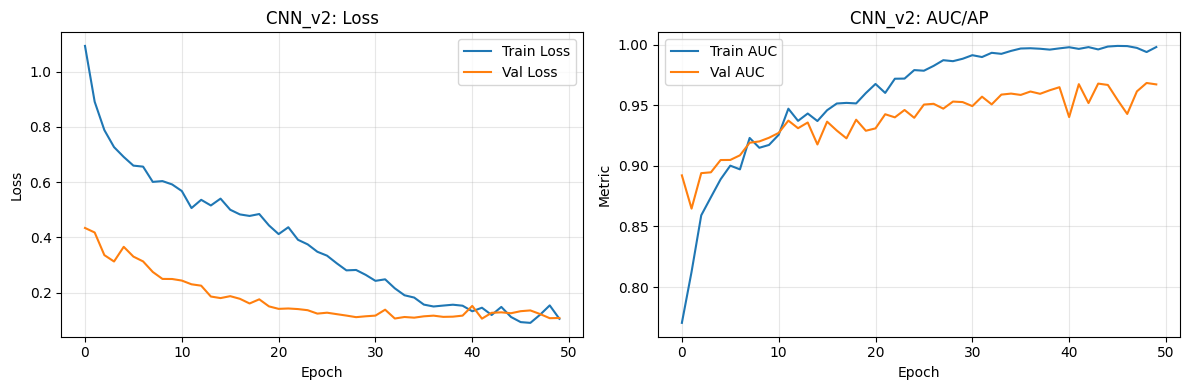

{'val_auroc': 0.9644077726784493,
 'val_auprc': 0.9147290771610045,
 'val_f1': 0.8602150537634409,
 'threshold': np.float32(0.1915493),
 'train_time_s': 84.33058857917786,
 'n_params': 93377,
 'model': <Sequential name=sequential_1, built=True>}

In [ ]:
# CNN v2: evaluation
evaluate_cnn(model_v2, 'CNN_v2', history_v2, time_v2, cnn_results)

**Takeaway:** GlobalMaxPooling drastically reduces parameters and is better suited for localized defects. The signal from a small scratch only needs to activate one spatial location per filter. Next: optimize hyperparameters on this architecture with keras-tuner.

### CNN v2 Tuned: Hyperparameter Optimization

Using keras-tuner RandomSearch to optimize filters, learning rate, and L2 regularization on the v2 architecture (3 conv layers + GlobalMaxPooling).

In [ ]:
# CNN v2_tuned: hypermodel (search space)

def build_cnn_v2_tuned(hp):
    filters = hp.Choice('filters', [16, 32, 64, 128])
    learning_rate = hp.Choice('learning_rate', [3e-5, 1e-4, 3e-4, 1e-3])
    l2_val = hp.Choice('l2', [0.0, 1e-5, 1e-4, 1e-3])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    reg = regularizers.l2(l2_val) if l2_val > 0 else None

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Conv2D(filters * 2, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Conv2D(filters * 4, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.GlobalMaxPooling2D(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='ap', curve='PR')]
    )
    return model

In [ ]:
# CNN v2_tuned: run RandomSearch and extract best HPs
tuner = kt.RandomSearch(
    hypermodel=build_cnn_v2_tuned,
    objective=kt.Objective('val_ap', direction='max'),
    max_trials=20,
    seed=SEED,
    directory='keras_tuner',
    project_name='cnn_v2_tuning',
    overwrite=True
)

tuner.search(
    X_train_sup, y_train_sup,
    validation_data=(X_val_sup, y_val_sup),
    epochs=CNN_EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_ap', mode='max', patience=8, restore_best_weights=True)
    ],
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(f"Best filters: {best_hp.get('filters')}")
print(f"Best learning_rate: {best_hp.get('learning_rate')}")
print(f"Best l2: {best_hp.get('l2')}")
print(f"Best dropout: {best_hp.get('dropout')}")

Trial 20 Complete [00h 00m 51s]
val_ap: 0.9067075252532959

Best val_ap So Far: 0.9306754469871521
Total elapsed time: 00h 37m 53s
Best filters: 128
Best learning_rate: 0.0001
Best l2: 1e-05
Best dropout: 0.3


In [ ]:
# Train best tuned model to completion
model_v2_tuned = tuner.hypermodel.build(best_hp)

t0 = time.time()
history_v2_tuned = model_v2_tuned.fit(
    X_train_sup, y_train_sup,
    validation_data=(X_val_sup, y_val_sup),
    epochs=100, batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_ap', mode='max', patience=8, restore_best_weights=True)
    ],
    verbose=2
)
time_v2_tuned = time.time() - t0

Epoch 1/100
59/59 - 6s - 100ms/step - ap: 0.5437 - auc: 0.7679 - loss: 1.1484 - val_ap: 0.7535 - val_auc: 0.8712 - val_loss: 0.5942
Epoch 2/100
59/59 - 2s - 34ms/step - ap: 0.6190 - auc: 0.8235 - loss: 0.9526 - val_ap: 0.7669 - val_auc: 0.8800 - val_loss: 0.3776
Epoch 3/100
59/59 - 2s - 34ms/step - ap: 0.6627 - auc: 0.8411 - loss: 0.8363 - val_ap: 0.7696 - val_auc: 0.8799 - val_loss: 0.3069
Epoch 4/100
59/59 - 2s - 34ms/step - ap: 0.6969 - auc: 0.8642 - loss: 0.7795 - val_ap: 0.7828 - val_auc: 0.8869 - val_loss: 0.2739
Epoch 5/100
59/59 - 2s - 34ms/step - ap: 0.7274 - auc: 0.8761 - loss: 0.7432 - val_ap: 0.7881 - val_auc: 0.8901 - val_loss: 0.2481
Epoch 6/100
59/59 - 2s - 34ms/step - ap: 0.7264 - auc: 0.8666 - loss: 0.7479 - val_ap: 0.7943 - val_auc: 0.8952 - val_loss: 0.2551
Epoch 7/100
59/59 - 2s - 34ms/step - ap: 0.7502 - auc: 0.8844 - loss: 0.7062 - val_ap: 0.7980 - val_auc: 0.8990 - val_loss: 0.2403
Epoch 8/100
59/59 - 2s - 34ms/step - ap: 0.7547 - auc: 0.8920 - loss: 0.6974 - val


[CNN_v2_tuned]
  Val: AUROC=0.9626, AUPRC=0.9276, F1=0.8913
  Threshold=0.2948, Params=1,479,425, Time=118.6s


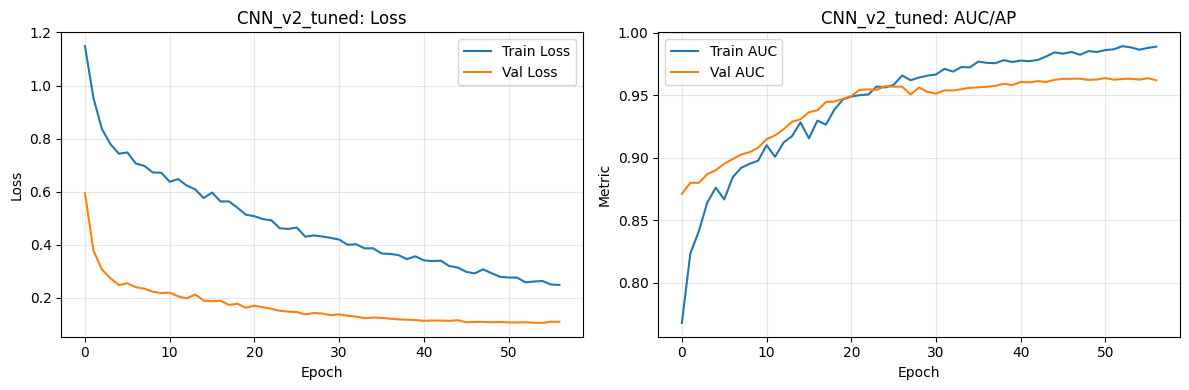

{'val_auroc': 0.9626013084659701,
 'val_auprc': 0.9276463030419675,
 'val_f1': 0.8913043478260869,
 'threshold': np.float32(0.29480973),
 'train_time_s': 118.64395380020142,
 'n_params': 1479425,
 'model': <Sequential name=sequential_1, built=True>}

In [ ]:
# CNN v2_tuned: evaluation
evaluate_cnn(model_v2_tuned, 'CNN_v2_tuned', history_v2_tuned, time_v2_tuned, cnn_results)

### ResNet50: Transfer Learning

Frozen ResNet50 backbone with a linear classification head. Leverages ImageNet features without fine-tuning the base model.

In [ ]:
# ResNet50: architecture
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_resnet.trainable = False

inputs = keras.Input(shape=INPUT_SHAPE)
x = preprocess_input(inputs * 255.0)
x = base_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_resnet = keras.Model(inputs, outputs, name='resnet50_transfer')
model_resnet.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 288, 96,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 288, 96,   │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 288, 96)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 288, 96)   │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 288, 96)   │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 288, 96,   │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 288, 96,   │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 9, 3,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ResNet50: compile and train
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='ap', curve='PR')]
)

t0 = time.time()
history_resnet = model_resnet.fit(
    X_train_sup, y_train_sup,
    validation_data=(X_val_sup, y_val_sup),
    epochs=CNN_EPOCHS, batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_ap', mode='max', patience=10, restore_best_weights=True)
    ],
    verbose=1
)
time_resnet = time.time() - t0


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - ap: 0.6294 - auc: 0.8472 - loss: 0.8331 - val_ap: 0.8628 - val_auc: 0.9574 - val_loss: 0.2135
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.7679 - auc: 0.9105 - loss: 0.6453 - val_ap: 0.8700 - val_auc: 0.9592 - val_loss: 0.2342
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - ap: 0.8097 - auc: 0.9231 - loss: 0.5877 - val_ap: 0.8771 - val_auc: 0.9604 - val_loss: 0.2438
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.8413 - auc: 0.9408 - loss: 0.5260 - val_ap: 0.8781 - val_auc: 0.9610 - val_loss: 0.2404
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.8409 - auc: 0.9462 - loss: 0.5081 - val_ap: 0.8795 - val_auc: 0.9617 - val_loss: 0.2268
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.8538 - auc: 0.9579 - loss: 0.4639 - val_ap: 0.8774 - val_auc: 0.9605 - val_loss: 0.2132
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ap: 0.8515 - auc: 0.9552 - loss: 0.4695 - val_ap: 0.8783 - val_


[ResNet50]
  Val: AUROC=0.9620, AUPRC=0.8810, F1=0.8444
  Threshold=0.8500, Params=23,850,113, Time=40.6s


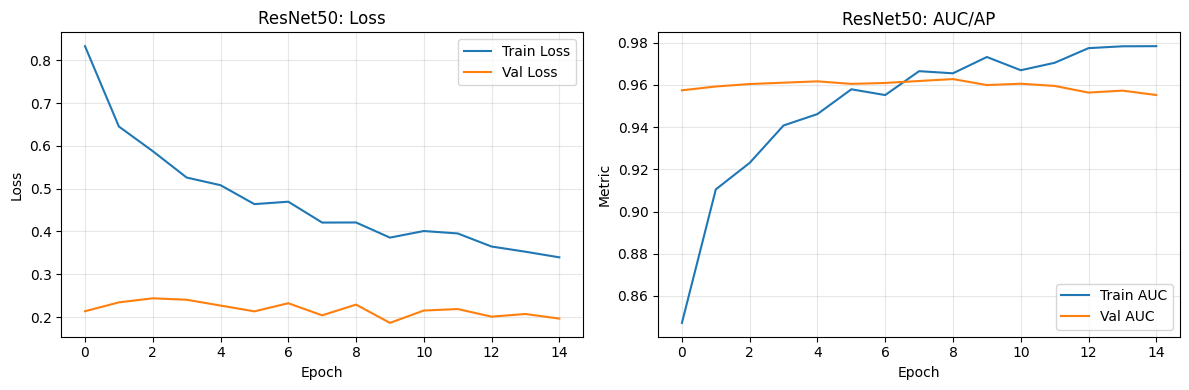

{'val_auroc': 0.9620154281808417,
 'val_auprc': 0.8809987028566233,
 'val_f1': 0.8444444444444444,
 'threshold': np.float32(0.849988),
 'train_time_s': 40.62112903594971,
 'n_params': 23850113,
 'model': <Functional name=resnet50_transfer, built=True>}

In [ ]:
# ResNet50: evaluation
evaluate_cnn(model_resnet, 'ResNet50', history_resnet, time_resnet, cnn_results)

In [ ]:
# CNN comparison table (validation only)
cnn_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'model'}
                       for k, v in cnn_results.items()}).T
print(cnn_df[['val_auroc', 'val_auprc', 'val_f1', 'n_params', 'train_time_s']].to_string())

best_cnn_name = cnn_df.drop('ResNet50').val_auprc.astype(float).idxmax()
print(f"\nBest CNN (by val AUPRC): {best_cnn_name}")

              val_auroc  val_auprc    val_f1    n_params  train_time_s
CNN_v1         0.827898   0.685730  0.683544    314433.0     40.299464
CNN_v2         0.964408   0.914729  0.860215     93377.0     84.330589
CNN_v2_tuned   0.962601   0.927646  0.891304   1479425.0    118.643954
ResNet50       0.962015   0.880999  0.844444  23850113.0     40.621129

Best CNN (by val AUPRC): CNN_v2_tuned


### Save checkpoint: CNN

In [ ]:
# Save CNN results
cnn_metrics_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'model'}
                               for k, v in cnn_results.items()}).T
cnn_metrics_df.to_csv(RESULTS_DIR / 'cnn_metrics.csv', index=False)
print(f"Saved CNN validation metrics for: {list(cnn_results.keys())}")

Saved CNN validation metrics for: ['CNN_v1', 'CNN_v2', 'CNN_v2_tuned', 'ResNet50']


## Final Comparison (Test Set Evaluation)

All model decisions were finalized on validation only, and the test set is evaluated here once per model with no threshold re-selection.
- **PCA / CAE:** model selected by unsupervised criteria (elbow, val_loss, CV), threshold set by p-quartile on normal validation scores.
- **CNN / ResNet-50:** architecture tuned on supervised validation, threshold from F1-max on validation.

In [ ]:
# Final test evaluation (done once here)
# PCA: score test set
pca_test_scores = reconstruction_error(X_test_centered, pca_final)
pca_test_auroc = roc_auc_score(y_test, pca_test_scores)
pca_test_auprc = average_precision_score(y_test, pca_test_scores)
pca_test_pred = (pca_test_scores >= pca_threshold).astype(int)
pca_test_f1 = f1_score(y_test, pca_test_pred)

# CAE: score test set with best model (using winning aggregation from sweep)
cae_test_scores = score_images(best_cae_model, X_test)
cae_test_auroc = roc_auc_score(y_test, cae_test_scores)
cae_test_auprc = average_precision_score(y_test, cae_test_scores)
cae_test_pred = (cae_test_scores >= cae_threshold).astype(int)
cae_test_f1 = f1_score(y_test, cae_test_pred)

# CNN: best from tuning (full-data run)
best_cnn_model = cnn_results[best_cnn_name]["model"]
best_cnn_threshold = cnn_results[best_cnn_name]["threshold"]
best_cnn_test_probs = best_cnn_model.predict(X_test, verbose=0).flatten()
best_cnn_test_auroc = roc_auc_score(y_test, best_cnn_test_probs)
best_cnn_test_auprc = average_precision_score(y_test, best_cnn_test_probs)
best_cnn_test_pred = (best_cnn_test_probs >= best_cnn_threshold).astype(int)
best_cnn_test_f1 = f1_score(y_test, best_cnn_test_pred)

# ResNet50: from tuning (full-data run)
resnet_model_final = cnn_results["ResNet50"]["model"]
resnet_threshold_final = cnn_results["ResNet50"]["threshold"]
resnet_test_probs = resnet_model_final.predict(X_test, verbose=0).flatten()
resnet_test_auroc = roc_auc_score(y_test, resnet_test_probs)
resnet_test_auprc = average_precision_score(y_test, resnet_test_probs)
resnet_test_pred = (resnet_test_probs >= resnet_threshold_final).astype(int)
resnet_test_f1 = f1_score(y_test, resnet_test_pred)

summary_data = [
    ['PCA', pca_test_auroc, pca_test_auprc, pca_test_f1,
     pca_final.n_components_, f"p{PCA_QUARTILE}"],

    ['CAE (best)', cae_test_auroc, cae_test_auprc, cae_test_f1,
      best_cae_model.count_params(), f'p{CAE_QUARTILE} normal recon.'],

    [best_cnn_name, best_cnn_test_auroc, best_cnn_test_auprc, best_cnn_test_f1,
     cnn_results[best_cnn_name]['n_params'], 'F1-max'],

    ['ResNet50', resnet_test_auroc, resnet_test_auprc, resnet_test_f1,
     cnn_results['ResNet50']['n_params'], 'F1-max'],
]

headers = ['Method', 'AUROC', 'AUPRC', 'F1', 'Parameters', 'Threshold']

table_formatted = []
for row in summary_data:
    table_formatted.append([
        row[0],
        f"{row[1]:.4f}",
        f"{row[2]:.4f}",
        f"{row[3]:.4f}",
        f"{row[4]:,}" if isinstance(row[4], (int, np.integer)) else str(row[4]),
        row[5]
    ])

print(tabulate(table_formatted, headers=headers, tablefmt='fancy_grid'))


╒══════════════╤═════════╤═════════╤════════╤══════════════╤═══════════════════╕
│ Method       │   AUROC │   AUPRC │     F1 │   Parameters │ Threshold         │
╞══════════════╪═════════╪═════════╪════════╪══════════════╪═══════════════════╡
│ PCA          │  0.7697 │  0.5114 │ 0.4344 │           39 │ p95               │
├──────────────┼─────────┼─────────┼────────┼──────────────┼───────────────────┤
│ CAE (best)   │  0.8969 │  0.6686 │ 0.5776 │      795,297 │ p95 normal recon. │
├──────────────┼─────────┼─────────┼────────┼──────────────┼───────────────────┤
│ CNN_v2_tuned │  0.9543 │  0.8945 │ 0.8056 │    1,479,425 │ F1-max            │
├──────────────┼─────────┼─────────┼────────┼──────────────┼───────────────────┤
│ ResNet50     │  0.9342 │  0.8356 │ 0.7749 │   23,850,113 │ F1-max            │
╘══════════════╧═════════╧═════════╧════════╧══════════════╧═══════════════════╛


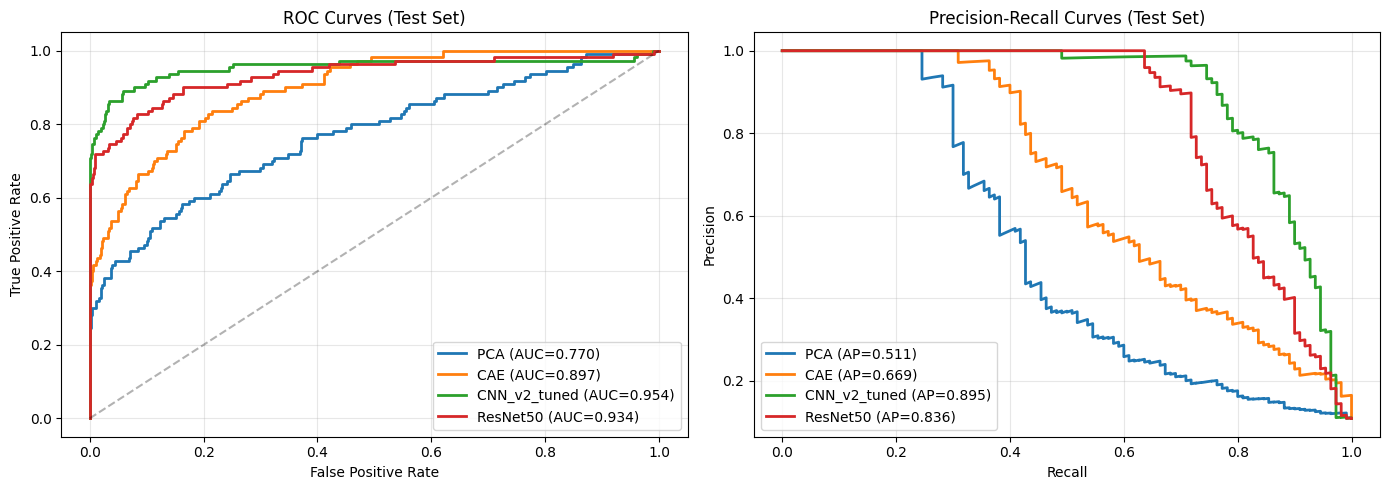

In [ ]:
# Overlaid ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for name, scores in [('PCA', pca_test_scores),
                      ('CAE', cae_test_scores),
                      (best_cnn_name, best_cnn_test_probs),
                      ('ResNet50', resnet_test_probs)]:
    fpr_plot, tpr_plot, _ = roc_curve(y_test, scores)
    auc_val = roc_auc_score(y_test, scores)
    ax1.plot(fpr_plot, tpr_plot, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves (Test Set)')
ax1.legend()
ax1.grid(alpha=0.3)

# PR
for name, scores in [('PCA', pca_test_scores),
                      ('CAE', cae_test_scores),
                      (best_cnn_name, best_cnn_test_probs),
                      ('ResNet50', resnet_test_probs)]:
    prec_plot, rec_plot, _ = precision_recall_curve(y_test, scores)
    ap_val = average_precision_score(y_test, scores)
    ax2.plot(rec_plot, prec_plot, label=f'{name} (AP={ap_val:.3f})', linewidth=2)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves (Test Set)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


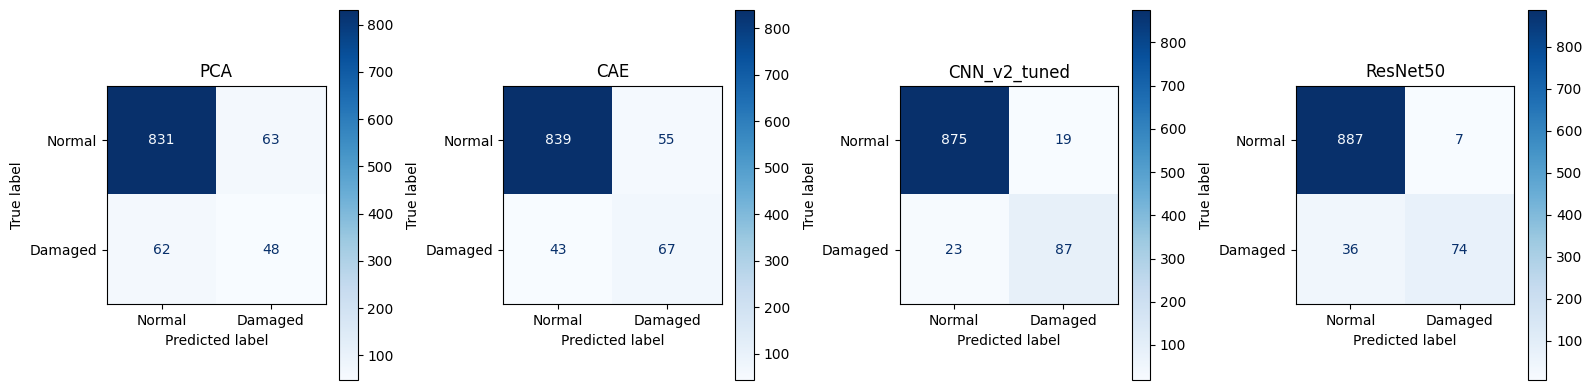

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

predictions = [
    ('PCA', pca_test_pred),
    ('CAE', cae_test_pred),
    (best_cnn_name, best_cnn_test_pred),
    ('ResNet50', resnet_test_pred),
]

for ax, (name, pred) in zip(axes, predictions):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Damaged']).plot(ax=ax, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Crossover Experiment: Label Efficiency

Given a fixed labeling budget of N defect examples, how do supervised methods (CNN, ResNet-50) perform compared to fully unsupervised baselines (PCA, CAE)? For each N in [5, 10, 25, 50, 75, 100, 150, all] we retrain the supervised models over 3 seeds and evaluate on the locked test set, while CAE and PCA stay fixed and appear as horizontal reference lines.
- **CNN:** trains on N x 0.8 defects plus all train normals, validates on N x 0.2 defects plus val normals.
- **ResNet-50:** same protocol as CNN.
- **CAE / PCA:** trained once on normals, threshold from p-quartile.

For N < 25 we use a fixed epoch count to avoid noisy early stopping on very few defects.

In [ ]:
# Crossover experiment setup
N_VALUES = [5, 10, 25, 50, 75, 100, 150, len(X_train_defects)]
N_SEEDS = 5

# Fixed epoch count for low-N runs (use stopping epoch from v2_tuned)
try:
    FIXED_EPOCHS = len(history_v2_tuned.history['loss'])
except (NameError, AttributeError):
    FIXED_EPOCHS = 30
print(f"Fixed epochs for N<25: {FIXED_EPOCHS}")
print(f"N values: {N_VALUES}")
print(f"Seeds: {N_SEEDS}")

Fixed epochs for N<25: 57
N values: [5, 10, 25, 50, 75, 100, 150, 197]
Seeds: 5


In [ ]:
# Crossover: model builders (CNN + ResNet50)

# Build the best CNN architecture (v2 tuned) for crossover experiment
def build_crossover_cnn():
    best_filters = best_hp.get('filters') if best_hp else 64
    best_l2 = best_hp.get('l2') if best_hp else 1e-5
    best_lr = best_hp.get('learning_rate') if best_hp else 3e-4
    best_dropout = best_hp.get('dropout') if best_hp else 0.3
    reg = regularizers.l2(best_l2) if best_l2 > 0 else None

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(best_filters, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Conv2D(best_filters * 2, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Conv2D(best_filters * 4, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.GlobalMaxPooling2D(),
        layers.Dropout(best_dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='ap', curve='PR')]
    )
    return model

# Build frozen ResNet50 transfer learning model for crossover experiment
def build_crossover_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base.trainable = False

    inputs = keras.Input(shape=INPUT_SHAPE)
    x = preprocess_input(inputs * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='resnet50_crossover')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='ap', curve='PR')]
    )
    return model


In [ ]:
# Crossover experiment loop (CNN + ResNet50)
crossover_results = []

# Pre-compute CAE and PCA test scores (fixed models, fixed thresholds)
cae_all_test_scores = score_images(best_cae_model, X_test)
pca_all_test_scores = reconstruction_error(X_test_centered, pca_final)

# Fixed test metrics for unsupervised methods
cae_test_auprc_fixed = average_precision_score(y_test, cae_all_test_scores)
pca_test_auprc_fixed = average_precision_score(y_test, pca_all_test_scores)
cae_f1_fixed = f1_score(y_test, (cae_all_test_scores >= cae_threshold).astype(int))
pca_f1_fixed = f1_score(y_test, (pca_all_test_scores >= pca_threshold).astype(int))

print(f"CAE fixed: AUPRC={cae_test_auprc_fixed:.4f}, F1={cae_f1_fixed:.4f}")
print(f"PCA fixed: AUPRC={pca_test_auprc_fixed:.4f}, F1={pca_f1_fixed:.4f}")
print()

for N in N_VALUES:
    n_seeds = 1 if N == len(X_train_defects) else N_SEEDS
    for seed in range(n_seeds):

        tf.keras.backend.clear_session()
        gc.collect()

        rng_exp = np.random.default_rng(seed + N * 1000)

        # Sample N defects from the train defect pool
        n_sample = min(N, len(X_train_defects))
        defect_idx = rng_exp.choice(len(X_train_defects), size=n_sample, replace=False)
        X_defects_N = X_train_defects[defect_idx]

        # Split sampled defects into train/val (80/20)
        n_cnn_train = max(1, int(n_sample * 0.8))
        cnn_train_def = X_defects_N[:n_cnn_train]
        cnn_val_def = X_defects_N[n_cnn_train:]

        X_cnn_train = np.concatenate([X_train_unsup, cnn_train_def])
        y_cnn_train = np.array([0]*len(X_train_unsup) + [1]*len(cnn_train_def))

        X_cnn_val = np.concatenate([X_val_normal, cnn_val_def])
        y_cnn_val = np.array([0]*len(X_val_normal) + [1]*len(cnn_val_def))

        cw_n = {0: 1.0, 1: len(X_train_unsup) / max(len(cnn_train_def), 1)}

        use_early_stop = N >= 25
        ep = CNN_EPOCHS if use_early_stop else FIXED_EPOCHS

        # Train CNN (fresh callbacks)
        tf.keras.utils.set_random_seed(seed)
        cnn_model = build_crossover_cnn()
        cnn_cbs = []
        if use_early_stop:
            cnn_cbs.append(callbacks.EarlyStopping(monitor='val_ap', mode='max',
                                                   patience=8, restore_best_weights=True))
        cnn_model.fit(
            X_cnn_train, y_cnn_train,
            validation_data=(X_cnn_val, y_cnn_val),
            epochs=ep, batch_size=BATCH,
            class_weight=cw_n, callbacks=cnn_cbs, verbose=0
        )

        # CNN test metrics
        cnn_val_probs = cnn_model.predict(X_cnn_val, verbose=0).flatten()
        prec_c, rec_c, thr_c = precision_recall_curve(y_cnn_val, cnn_val_probs)
        f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
        cnn_thr = thr_c[np.argmax(f1_c)]

        cnn_test_probs = cnn_model.predict(X_test, verbose=0).flatten()
        cnn_auprc = average_precision_score(y_test, cnn_test_probs)
        cnn_f1 = f1_score(y_test, (cnn_test_probs >= cnn_thr).astype(int))

        # Train ResNet50 (fresh callbacks, separate config)
        tf.keras.utils.set_random_seed(seed)
        resnet_model = build_crossover_resnet()
        resnet_cbs = []
        if use_early_stop:
            resnet_cbs.append(callbacks.EarlyStopping(monitor='val_ap', mode='max',
                                                      patience=10, restore_best_weights=True))
        resnet_model.fit(
            X_cnn_train, y_cnn_train,
            validation_data=(X_cnn_val, y_cnn_val),
            epochs=ep, batch_size=BATCH,
            class_weight=cw_n, callbacks=resnet_cbs, verbose=0
        )

        # ResNet50 test metrics
        resnet_val_probs = resnet_model.predict(X_cnn_val, verbose=0).flatten()
        prec_r, rec_r, thr_r = precision_recall_curve(y_cnn_val, resnet_val_probs)
        f1_r = 2 * prec_r[:-1] * rec_r[:-1] / (prec_r[:-1] + rec_r[:-1] + 1e-8)
        resnet_thr = thr_r[np.argmax(f1_r)]

        resnet_test_probs = resnet_model.predict(X_test, verbose=0).flatten()
        resnet_auprc = average_precision_score(y_test, resnet_test_probs)
        resnet_f1 = f1_score(y_test, (resnet_test_probs >= resnet_thr).astype(int))

        crossover_results.append({
            'N': N, 'seed': seed,
            'cnn_auprc': cnn_auprc, 'cnn_f1': cnn_f1,
            'resnet_auprc': resnet_auprc, 'resnet_f1': resnet_f1,
            'cae_auprc': cae_test_auprc_fixed, 'cae_f1': cae_f1_fixed,
            'pca_auprc': pca_test_auprc_fixed, 'pca_f1': pca_f1_fixed
        })

        print(f"  N={N:>4d} seed={seed}: CNN_AUPRC={cnn_auprc:.3f} ResNet_AUPRC={resnet_auprc:.3f}")

        del cnn_model, resnet_model
        gc.collect()

crossover_df = pd.DataFrame(crossover_results)
print(f"\nCompleted {len(crossover_df)} runs.")


CAE fixed: AUPRC=0.6686, F1=0.5776
PCA fixed: AUPRC=0.5114, F1=0.4344



  N=   5 seed=0: CNN_AUPRC=0.551 ResNet_AUPRC=0.154
  N=   5 seed=1: CNN_AUPRC=0.671 ResNet_AUPRC=0.075
  N=   5 seed=2: CNN_AUPRC=0.300 ResNet_AUPRC=0.063
  N=   5 seed=3: CNN_AUPRC=0.686 ResNet_AUPRC=0.080
  N=   5 seed=4: CNN_AUPRC=0.629 ResNet_AUPRC=0.445
  N=  10 seed=0: CNN_AUPRC=0.652 ResNet_AUPRC=0.512
  N=  10 seed=1: CNN_AUPRC=0.549 ResNet_AUPRC=0.479
  N=  10 seed=2: CNN_AUPRC=0.751 ResNet_AUPRC=0.587
  N=  10 seed=3: CNN_AUPRC=0.559 ResNet_AUPRC=0.065
  N=  10 seed=4: CNN_AUPRC=0.654 ResNet_AUPRC=0.224
  N=  25 seed=0: CNN_AUPRC=0.671 ResNet_AUPRC=0.812
  N=  25 seed=1: CNN_AUPRC=0.768 ResNet_AUPRC=0.754
  N=  25 seed=2: CNN_AUPRC=0.723 ResNet_AUPRC=0.778
  N=  25 seed=3: CNN_AUPRC=0.703 ResNet_AUPRC=0.695
  N=  25 seed=4: CNN_AUPRC=0.667 ResNet_AUPRC=0.686
  N=  50 seed=0: CNN_AUPRC=0.789 ResNet_AUPRC=0.794
  N=  50 seed=1: CNN_AUPRC=0.820 ResNet_AUPRC=0.804
  N=  50 seed=2: CNN_AUPRC=0.655 ResNet_AUPRC=0.802
  N=  50 seed=3: CNN_AUPRC=0.666 ResNet_AUPRC=0.807
  N=  50 see

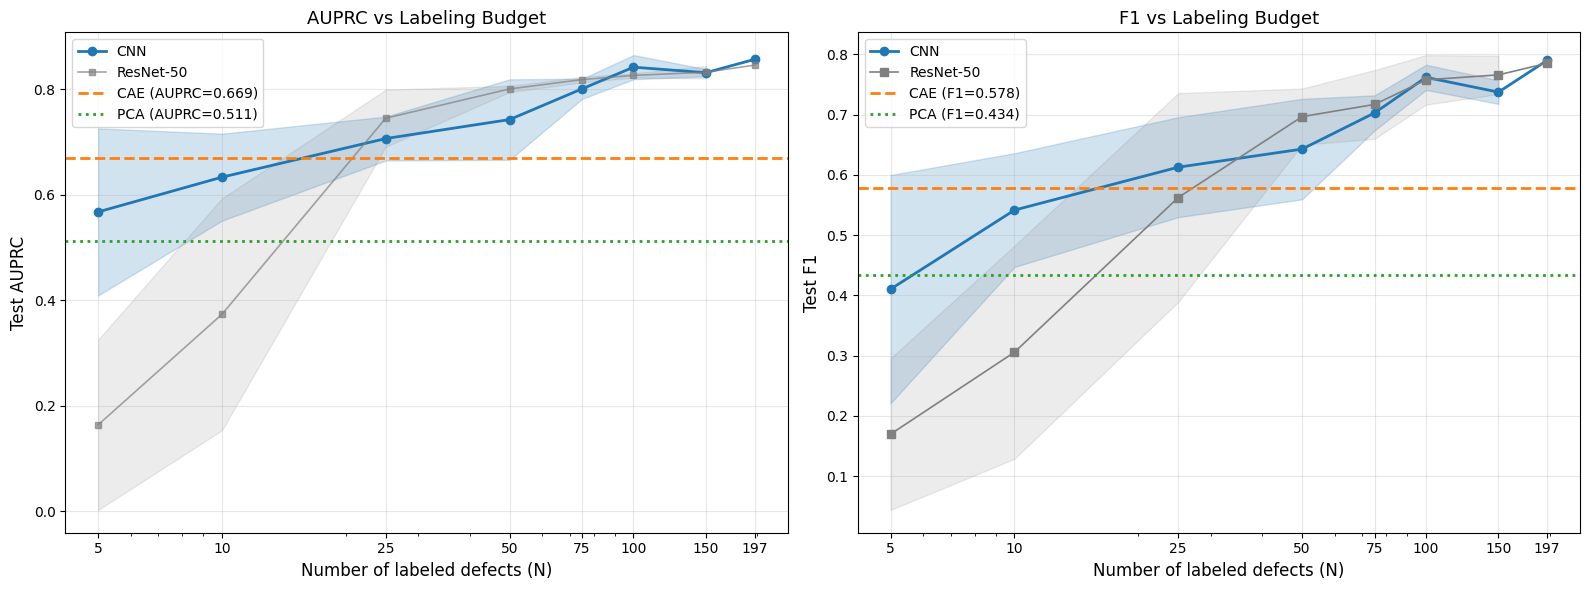


Crossover (AUPRC): CNN surpasses CAE at N=25
Crossover (AUPRC): ResNet-50 surpasses CAE at N=25


In [ ]:
# Crossover plot: AUPRC + F1 vs N
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: AUPRC
cnn_auprc_stats = crossover_df.groupby('N')['cnn_auprc'].agg(['mean', 'std']).reset_index()
resnet_auprc_stats = crossover_df.groupby('N')['resnet_auprc'].agg(['mean', 'std']).reset_index()

ax1.plot(cnn_auprc_stats['N'], cnn_auprc_stats['mean'], 'o-', color='tab:blue',
         label='CNN', linewidth=2)
ax1.fill_between(cnn_auprc_stats['N'],
                 cnn_auprc_stats['mean'] - cnn_auprc_stats['std'],
                 cnn_auprc_stats['mean'] + cnn_auprc_stats['std'],
                 alpha=0.2, color='tab:blue')

# ResNet-50: thin gray, mean only, no band
ax1.plot(resnet_auprc_stats['N'], resnet_auprc_stats['mean'], 's-', color='gray',
         label='ResNet-50', linewidth=1.2, markersize=4, alpha=0.7)

ax1.fill_between(resnet_auprc_stats['N'],
                 resnet_auprc_stats['mean'] - resnet_auprc_stats['std'],
                 resnet_auprc_stats['mean'] + resnet_auprc_stats['std'],
                 alpha=0.15, color='gray')

ax1.axhline(cae_test_auprc_fixed, color='tab:orange', linestyle='--', linewidth=2,
            label=f'CAE (AUPRC={cae_test_auprc_fixed:.3f})')
ax1.axhline(pca_test_auprc_fixed, color='tab:green', linestyle=':', linewidth=2,
            label=f'PCA (AUPRC={pca_test_auprc_fixed:.3f})')

ax1.set_xlabel('Number of labeled defects (N)', fontsize=12)
ax1.set_ylabel('Test AUPRC', fontsize=12)
ax1.set_title('AUPRC vs Labeling Budget', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xscale('log')
ax1.set_xticks(N_VALUES)
ax1.set_xticklabels([str(n) for n in N_VALUES])

# Right panel: F1
cnn_f1_stats = crossover_df.groupby('N')['cnn_f1'].agg(['mean', 'std']).reset_index()
resnet_f1_stats = crossover_df.groupby('N')['resnet_f1'].agg(['mean', 'std']).reset_index()

ax2.plot(cnn_f1_stats['N'], cnn_f1_stats['mean'], 'o-', color='tab:blue',
         label='CNN', linewidth=2)
ax2.fill_between(cnn_f1_stats['N'], cnn_f1_stats['mean'] - cnn_f1_stats['std'],
                 cnn_f1_stats['mean'] + cnn_f1_stats['std'], alpha=0.2, color='tab:blue')

ax2.plot(resnet_f1_stats['N'], resnet_f1_stats['mean'], 's-', color='gray',
         label='ResNet-50', linewidth=1.2)

ax2.fill_between(resnet_f1_stats['N'],
                 resnet_f1_stats['mean'] - resnet_f1_stats['std'],
                 resnet_f1_stats['mean'] + resnet_f1_stats['std'],
                 alpha=0.15, color='gray')

ax2.axhline(cae_f1_fixed, color='tab:orange', linestyle='--', linewidth=2,
            label=f'CAE (F1={cae_f1_fixed:.3f})')
ax2.axhline(pca_f1_fixed, color='tab:green', linestyle=':', linewidth=2,
            label=f'PCA (F1={pca_f1_fixed:.3f})')

ax2.set_xlabel('Number of labeled defects (N)', fontsize=12)
ax2.set_ylabel('Test F1', fontsize=12)
ax2.set_title('F1 vs Labeling Budget', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')
ax2.set_xticks(N_VALUES)
ax2.set_xticklabels([str(n) for n in N_VALUES])

plt.tight_layout()
plt.show()

# Identify crossover points
crossover_n_cnn = None
for _, row in cnn_auprc_stats.iterrows():
    if row['mean'] > cae_test_auprc_fixed:
        crossover_n_cnn = int(row['N'])
        break

crossover_n_resnet = None
for _, row in resnet_auprc_stats.iterrows():
    if row['mean'] > cae_test_auprc_fixed:
        crossover_n_resnet = int(row['N'])
        break

print(f"\nCrossover (AUPRC): CNN surpasses CAE at N={crossover_n_cnn or 'never'}")
print(f"Crossover (AUPRC): ResNet-50 surpasses CAE at N={crossover_n_resnet or 'never'}")


### Save checkpoint: Crossover

In [ ]:
# Save crossover results
crossover_df.to_csv(RESULTS_DIR / 'crossover_results.csv', index=False)
print("Saved: crossover_results.csv")

Saved: crossover_results.csv
